## Train a K-Means Clustering Model
The model will be trained using pandas and scikit-learn.
The model will be trained from data found at https://www.kaggle.com/datasets/itssuru/loan-data

I am running this through VS Code, using a docker container. You may also use the `ipynb` file in other Jupyter Notebook style setups. Consult Jupyter Notebook for options.

**To download the data, run this cell.**

Running this cell will download the data, if you are running it in the docker container. If not, you will need to navigate to the `KAGGLE_DATA_URL` and download the data manually.

In [1]:
import os
from data import download_kaggle_dataset
KAGGLE_DATA_URL = "https://www.kaggle.com/datasets/itssuru/loan-data"
DATA_PATH = os.path.join(os.getcwd(), "data", "k_means")
download_kaggle_dataset(KAGGLE_DATA_URL, DATA_PATH)

100%|██████████| 213k/213k [00:00<00:00, 7.12MB/s]

Extracting files...
Dataset cached at: /root/.cache/kagglehub/datasets/itssuru/loan-data/versions/1
Copied loan_data.csv to /workspaces/MS365/src/data/k_means


**Import the necessary python packages**

Import `itertools`, `pandas`, `numpy`, `sklearn.preprocessing.MinMaxScaler`, `sklearn.preprocessing.OneHotEncoder`, `sklearn.cluster.KMeans`, `sklearn.metrics.pairwise_distances`,  `sklearn.decomposition.TruncatedSVD`, `sklearn.decomposition.PCA`, and `matplotlib.pyplot`. Typically, packages such as `pandas`, `numpy`, and `matplotlib.pyplot` are imported with an allias. I will not be following that strategy here. 

The default size of the plots from `matplotlib.pyplot` is 6.4 inches by 4.8 inches ([width by height](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html)). I wll be setting them to 20 inches by 5 inches. This will create a more readable output. Depending on your screen size, you may want to change this for your own use. 

By default, `pandas` will truncate datasets with a lot of rows and a lot of columns. You can alter this functionality with the `set_option()` function. I have set it to show all possible columns. This could result in long run times for cells where you are displaying the data, if there are many columns to display. This will be expected behavior for this analysis.

If you are running the docker container or if you are using [Google Colab](https://colab.research.google.com/), the `pip install` has already been done. If not, then please consult your jupyter notebook environment docs for how to install the needed packages.

In [2]:
import itertools
import pandas
import numpy
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import TruncatedSVD, PCA
import matplotlib.pyplot

matplotlib.pyplot.rcParams["figure.figsize"] = [20, 5]
pandas.set_option("display.max_columns", None)

**Import and Review Data**

Import the data downloaded from the Kaggle site. The file name is `loan_data.csv`. Import it into `df` using `pandas.read_csv()`. The file is a typical CSV file, separated by commas.

The column names contain dots to separate words. Change those to underscores using `df.columns.str.replace()`. Underscores tend to be a common strategy for separating words in a column header.

Display the top rows of the dataframe using the `head()` method. The default value is `n=5`. Change the value if you want to see more or less rows.

In [3]:
df = pandas.read_csv(os.path.join(DATA_PATH, "loan_data.csv"))
df.columns = df.columns.str.replace(".", "_")
df.head(n=15)

,credit_policy,purpose,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
5,1,credit_card,0.0788,125.13,11.904968,16.98,727,6120.041667,50807,51.0,0,0,0,0
6,1,debt_consolidation,0.1496,194.02,10.714418,4.00,667,3180.041667,3839,76.8,0,0,1,1
7,1,all_other,0.1114,131.22,11.002100,11.08,722,5116.000000,24220,68.6,0,0,0,1
8,1,home_improvement,0.1134,87.19,11.407565,17.25,682,3989.000000,69909,51.1,1,0,0,0
9,1,debt_consolidation,0.1221,84.12,10.203592,10.00,707,2730.041667,5630,23.0,1,0,0,0


The top 15 rows of the data show the type of data that will be used to train the K-Means Clustering model. The model will require numerical data. The only column that will not work for our analysis is `purpose`. The data can be removed from the dataframe, or it can be encoded. Given that it is nominal categorical data, the best option will be to one-hot encode the data.

The other concern is if there are any missing values. Running [`describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) on the data will show the counts for each of the columns. The default output of the describe method will typically only show numerical values. To get a count for all the columns, the `include="all"` parameter can be used. Reviewing the count for each column, the data show that all columns contain the same number of counts. This means there are not any missing values in any of the columns. Nothing needs to be done to correct for missing data.

In [4]:
df.describe(include="all")

,credit_policy,purpose,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid
count,9578.000000,9578,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
unique,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,debt_consolidation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,3957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.804970,NaN,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,NaN,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,NaN,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,NaN,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,NaN,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,NaN,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000


**Clean the Data**

The data need to be numerical to work with the K-Means Clustering model. The column `purpose` will need to be one-hot encoded to be useful for this analysis. Create a one-hot encoder entity using [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html); include the parameter `sparse_output=False`. Assign the one-hot encoder to `ohe`. Review the documentation for `OneHotEncoder` if you want to better understand the different parameters that can be used and their function.

Use the `fit_transform` method to convert the data from the `purpose` column to one-hot encoded columns of data. The `fit_transform` requires an array-like object with n number of samples and n number of features. This can be resolved by passing in a dataframe object. Create a dataframe object from the `purpose` column by wrapping the column name by two square brackets `[[purpose]]`. Pass this value in to the `ohe.fit_transform` method. The `fit_transform` method will return an array of arrays filled with 0s and 1s. Save this information to `purpose_encoded`.

Create a pandas DataFrame from the `purpose_encoded` data and the `ohe.get_feature_names_out()` method. Pass those two values in to the `pandas.DataFrame` method. This will create a dataframe with the needed data.

Drop the `purpose` column using the `drop()` method for pandas Dataframes. Using the `inplace=True` replaces the dataframe in place and should not create a copy.

Merge the new `purpose_df` dataframe with the `df` dataframe created earlier. Merge the two dataframes on the indexes using [`pandas.merge`](https://pandas.pydata.org/docs/reference/api/pandas.merge.html). Review the documentation to better understand the parameters and their uses. Save the result of the merge to `df`, overwriting the original `df` value created earlier.

In [5]:
ohe = OneHotEncoder(sparse_output=False)
purpose_encoded = ohe.fit_transform(df[["purpose"]])
purpose_df = pandas.DataFrame(purpose_encoded, columns=ohe.get_feature_names_out())
df.drop(columns="purpose", inplace=True)
df = pandas.merge(df, purpose_df, left_index=True, right_index=True)

**K-Means Clustering Model Assumptions**

The K-Means Clustering Model makes [assumptions](https://www.geeksforgeeks.org/machine-learning/demonstration-of-k-means-assumptions/) about the kind of data that ara analyzed.
1. The data clusters are spherical and isotropic
2. The data clusters all have the same variance.
3. The data clusters are similar sizes

Plotting the data in a scatter plot can be a good way to show the shape of the data. However, if you have anything greater than 2 dimensions, this will be challenging. There are 27 columns in `df`, after dropping the column `purpose`, which means there are 27 dimensions of data to plot.

It is possible to similate this by plotting each of the columns against the others, which will show the shape of the data for each of the data points, when compared to the other data points. This is not necessarily the best way, but will show the shape of the data. If any of the data points are not spherical and isotropic, then those data points would be violating the first assumption of the K-Means clustering model.

The columns that contain binary data will naturaly create more linear plots, which means they will violate the first assumption. Since this is a known issue, those columns can be skipped and only the other columns can be plotted.

Create a list of columns where the max value in the column is greater than 1. Save it in `columns_to_plot`. I have done this with a [list comprehension](https://www.geeksforgeeks.org/python/python-list-comprehension/).

Create a set of unique columns, called `unique_columns`. Use `itertools.combinations` to create an iterable item of combinations, where combinations are not duplicated. For example, if `AB` are one combination, then `BA` will not be created. This is desired since we are plotting the points and a plot of `AB` will be the same as the plot of `BA`.

Loop through all the values in `unique_columns`, creating a scatter plot for each column combination and displaying the results. It will result in 45 plots.

Review the created plots. You will see that the data are not necessarily the best shape for the K-Means analysis, since very few of the plots show a spherical and isotropic shape.

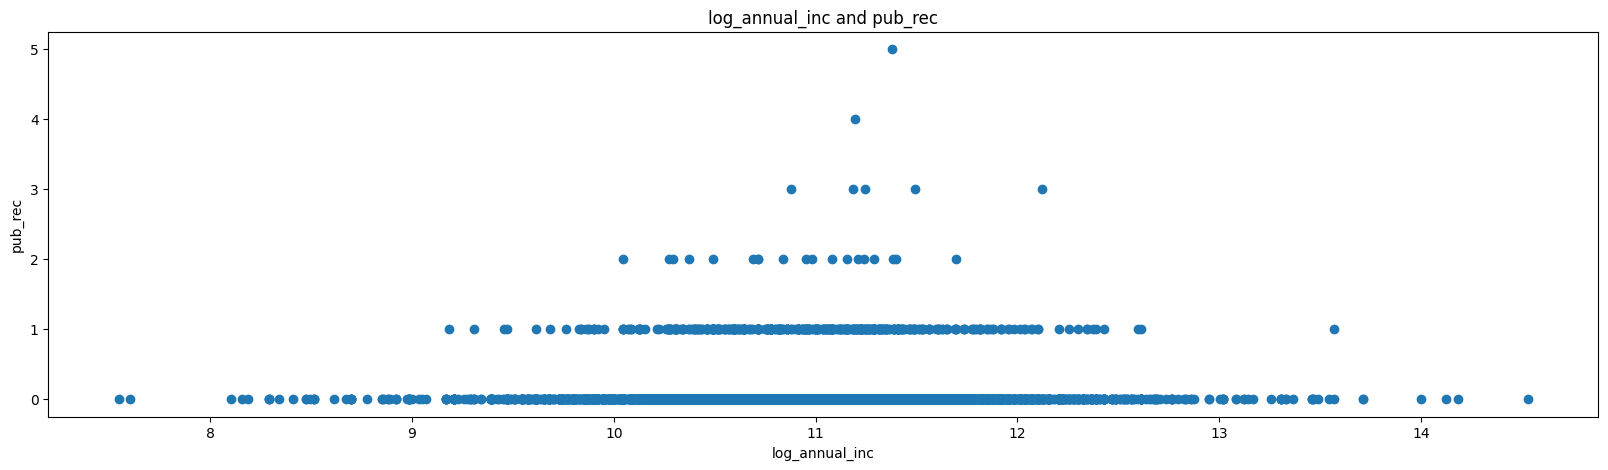

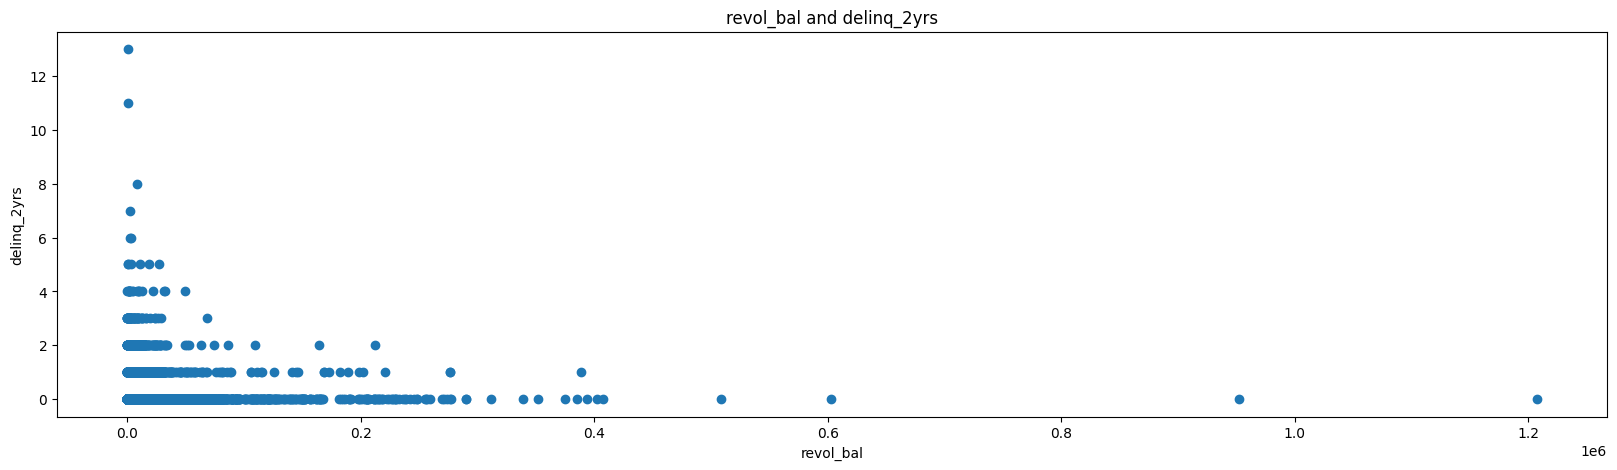

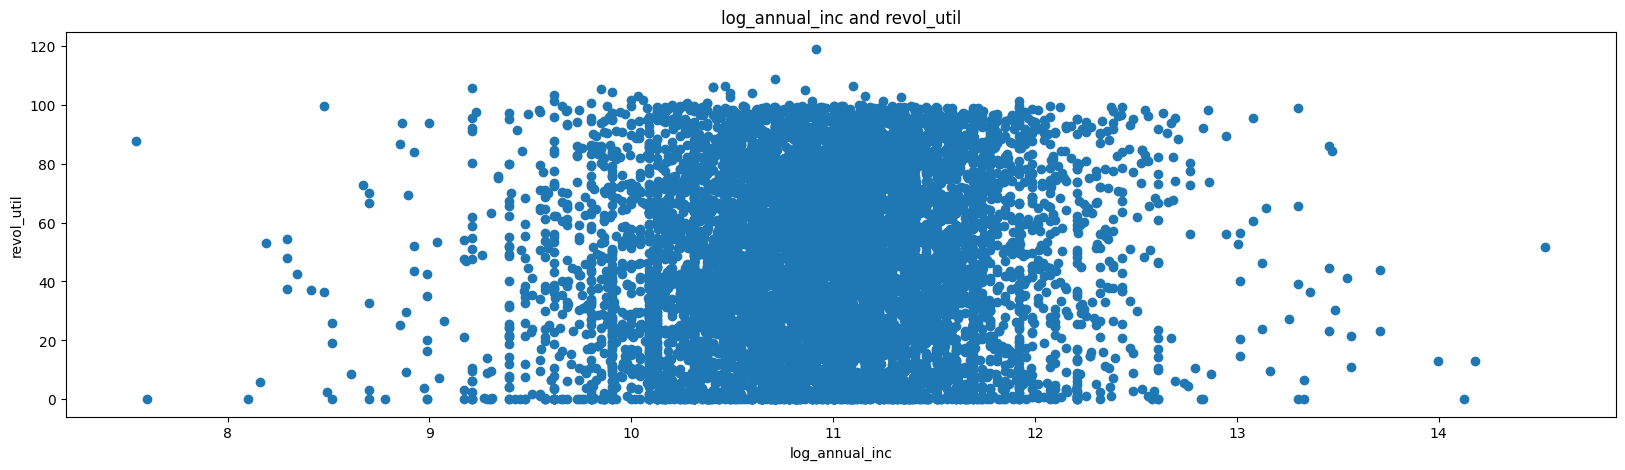

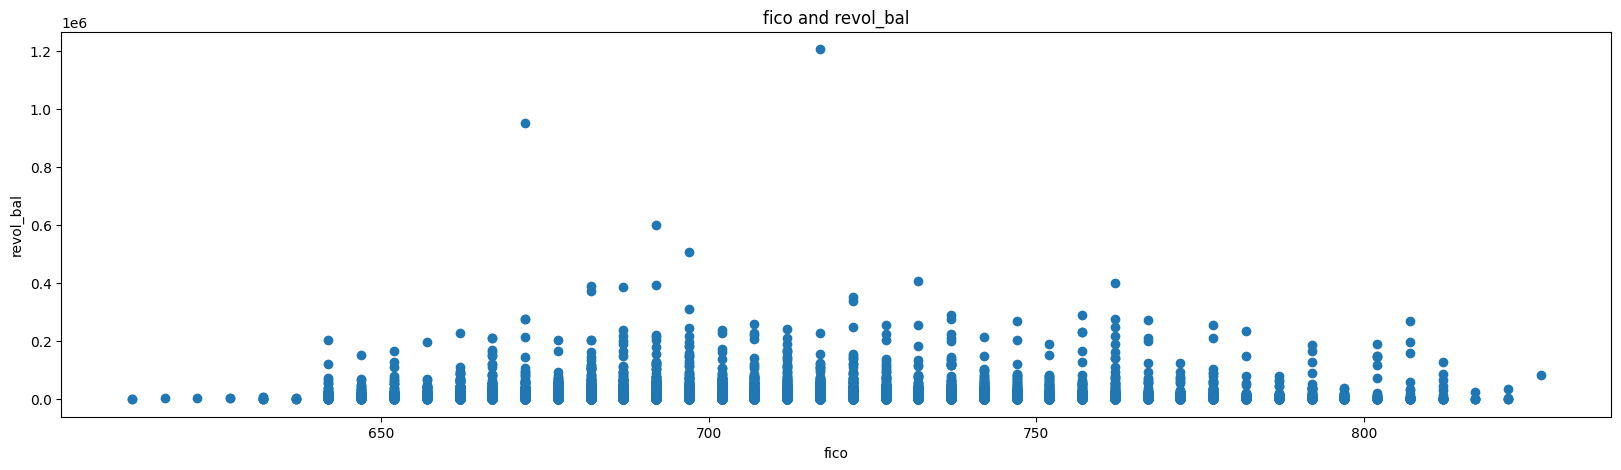

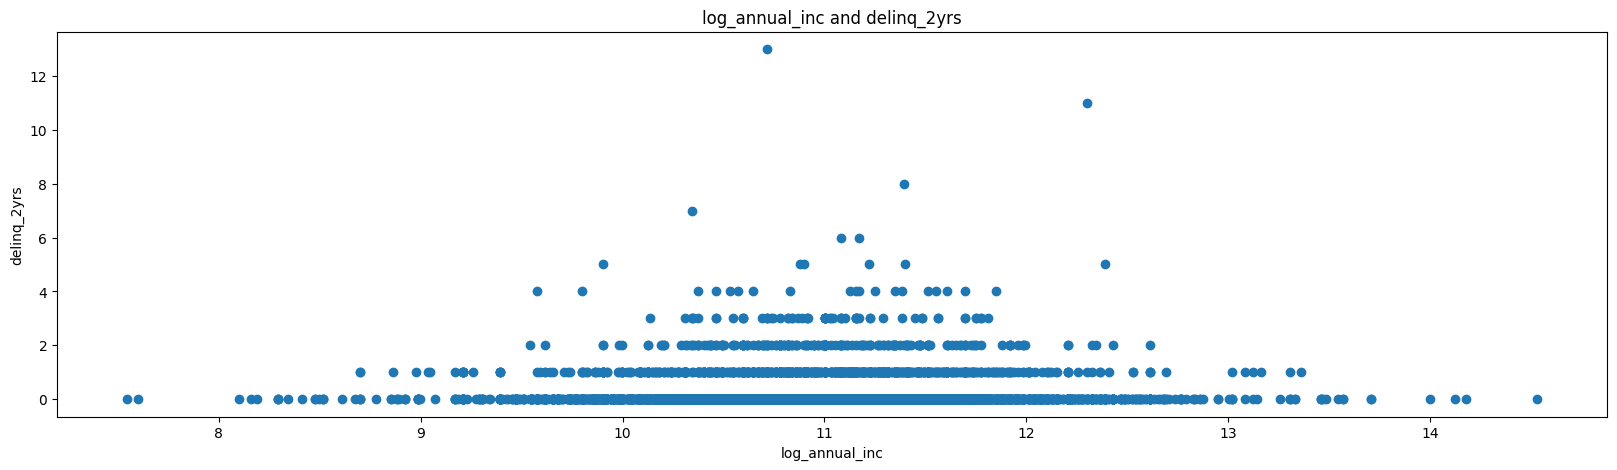

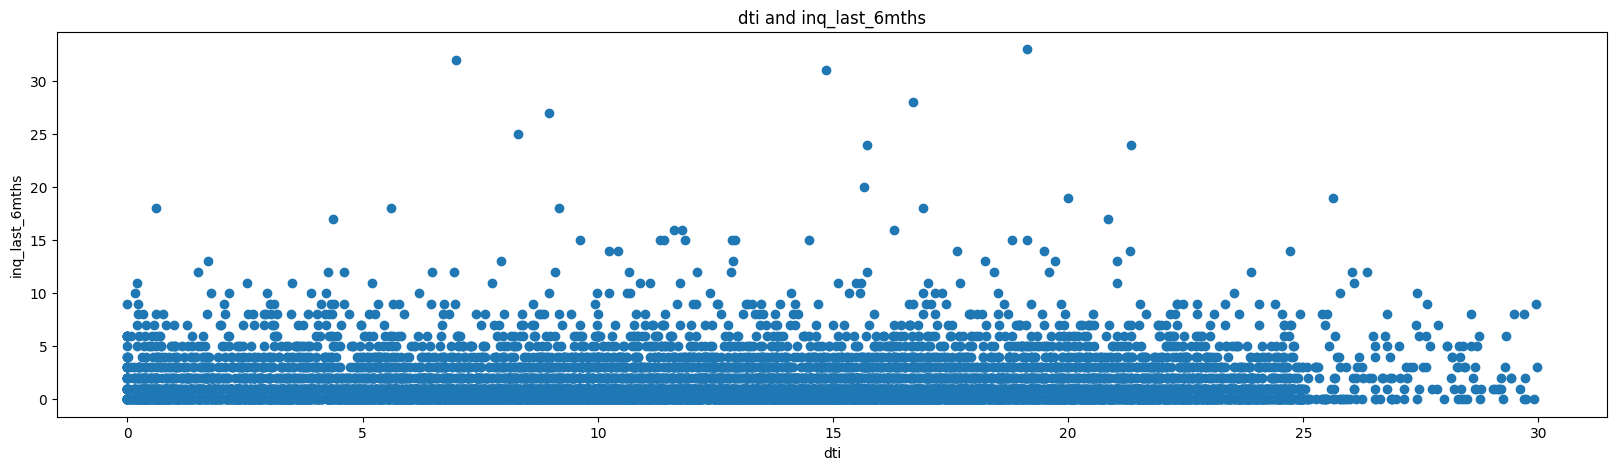

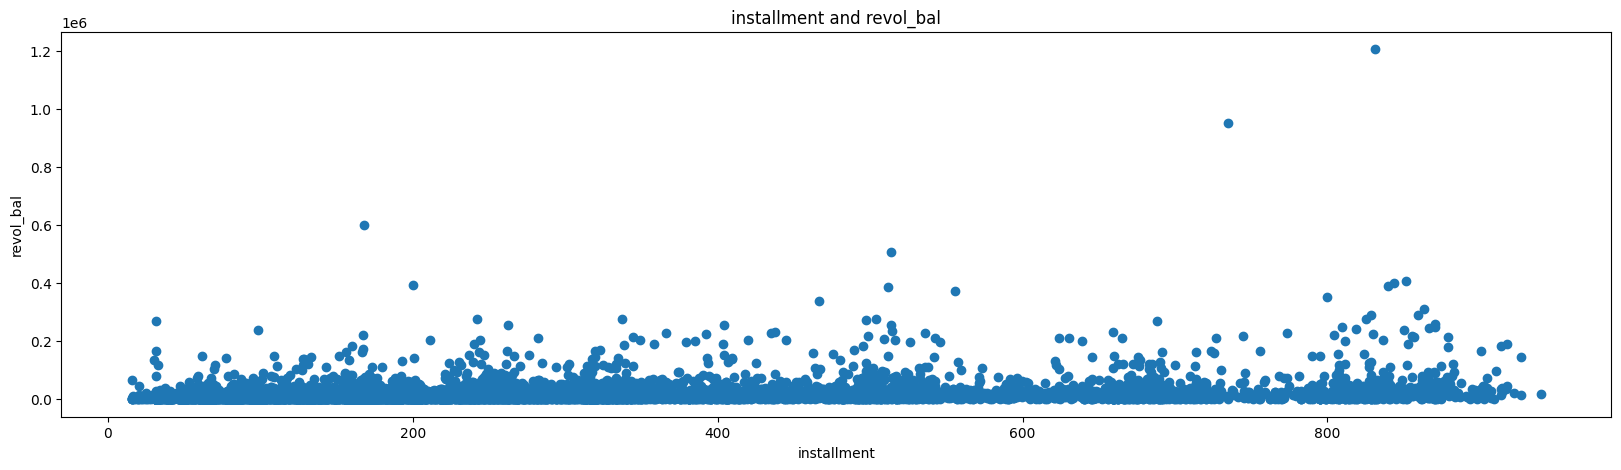

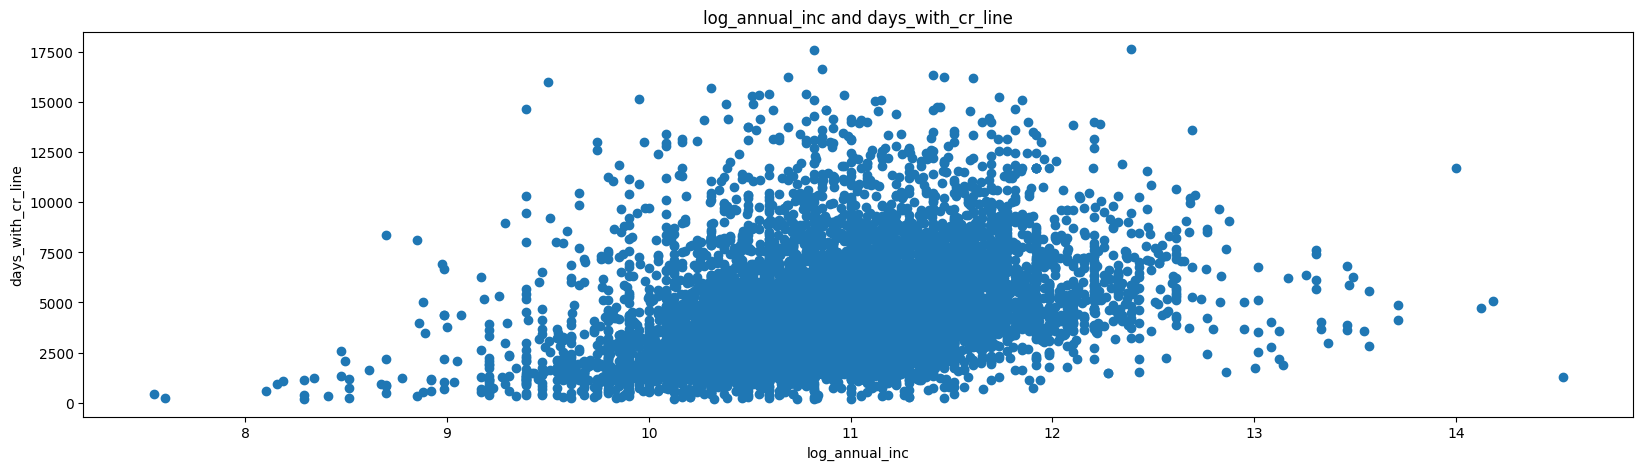

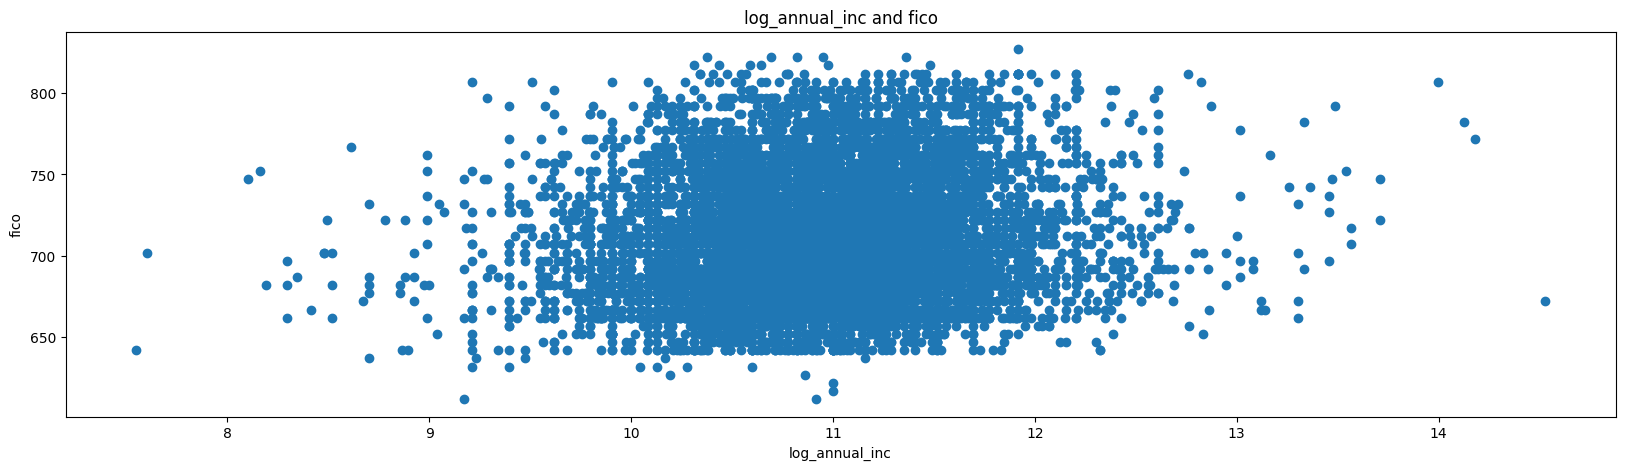

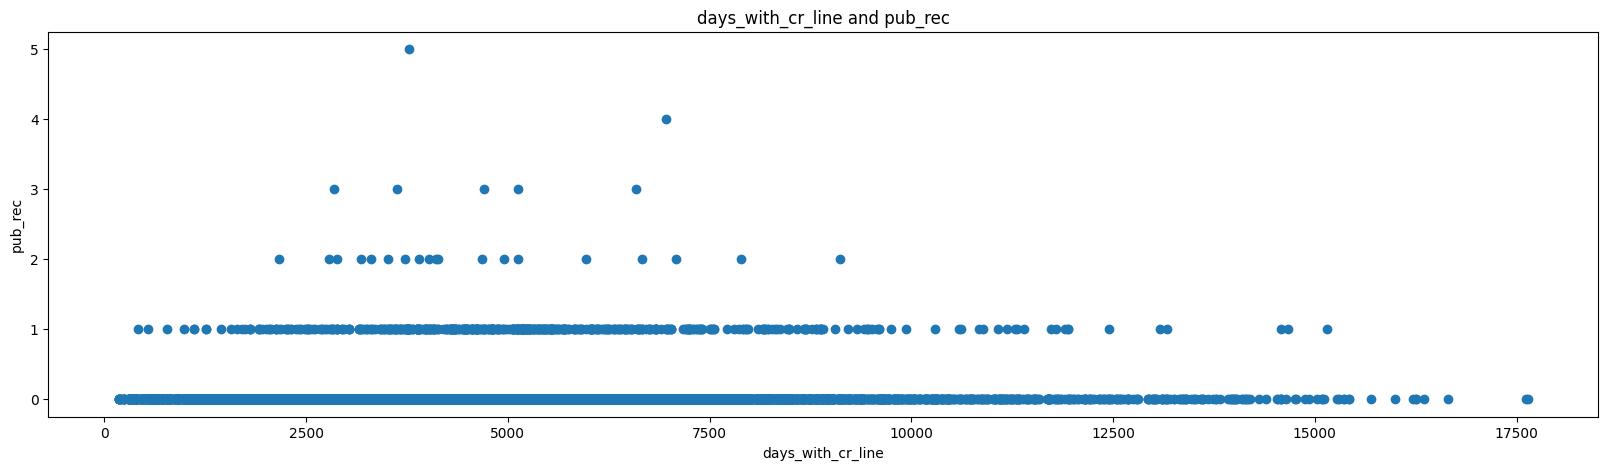

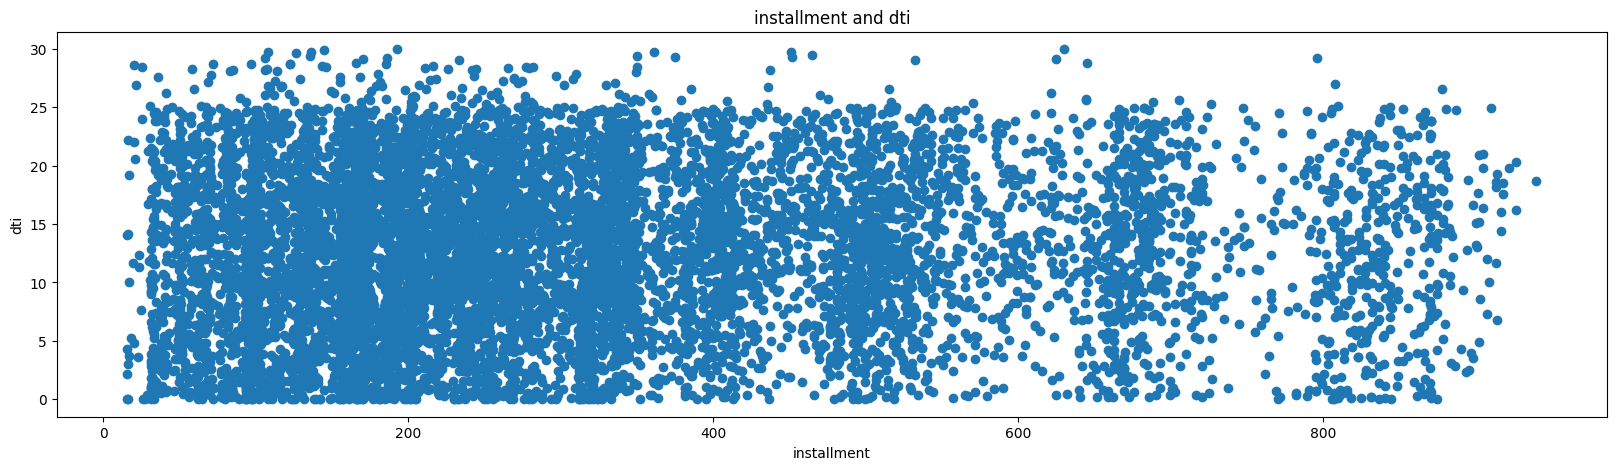

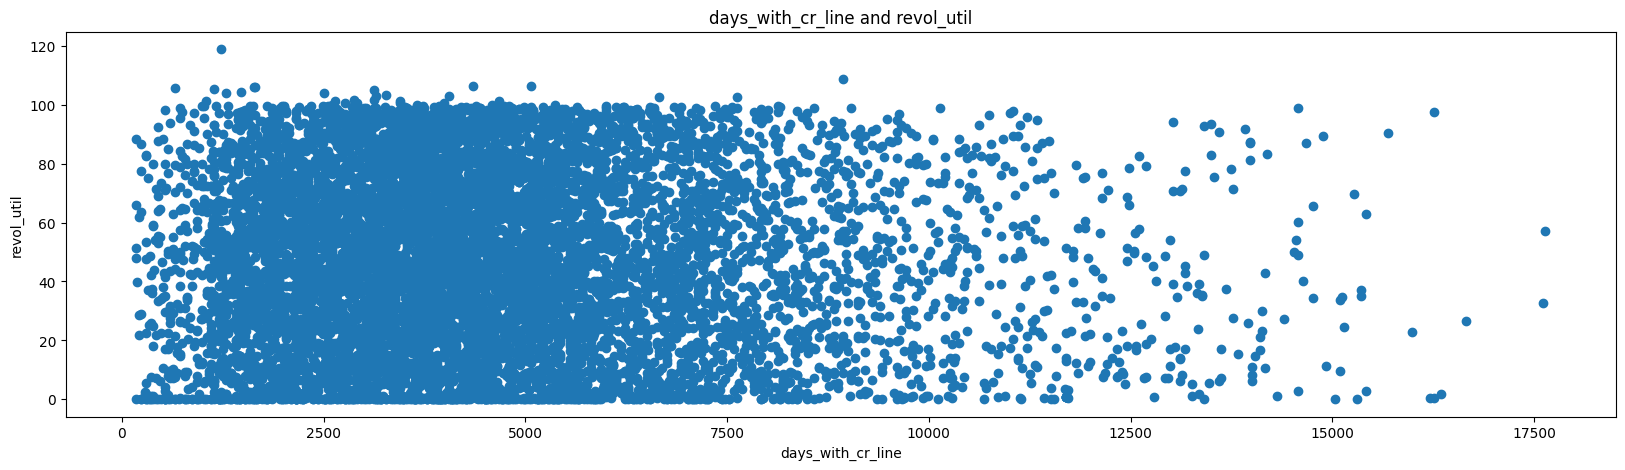

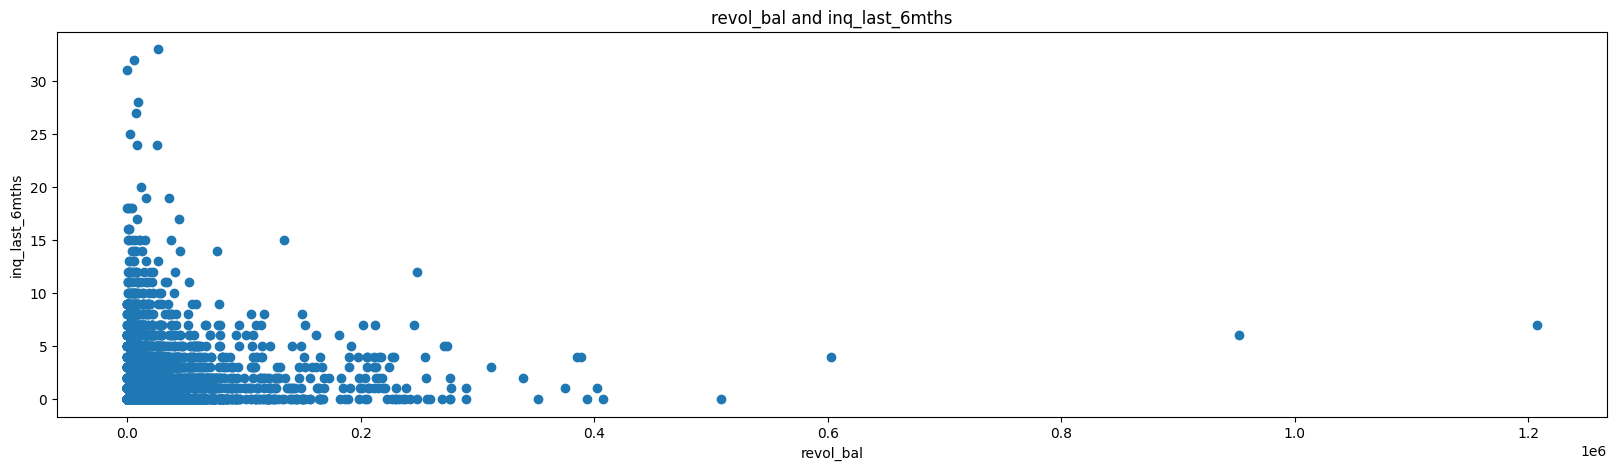

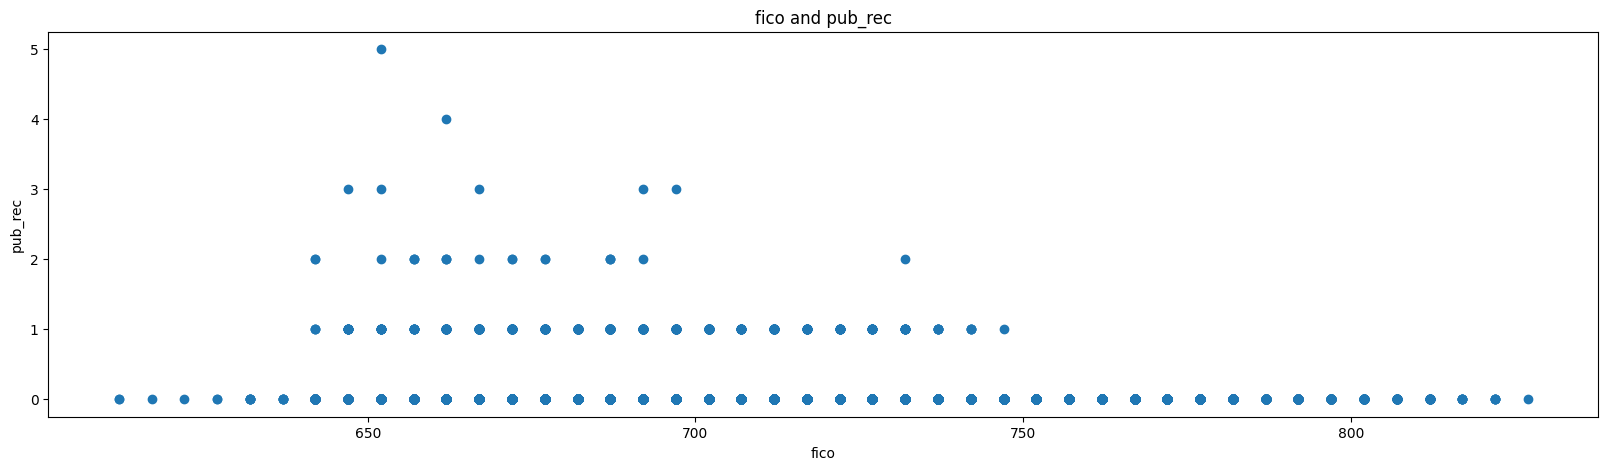

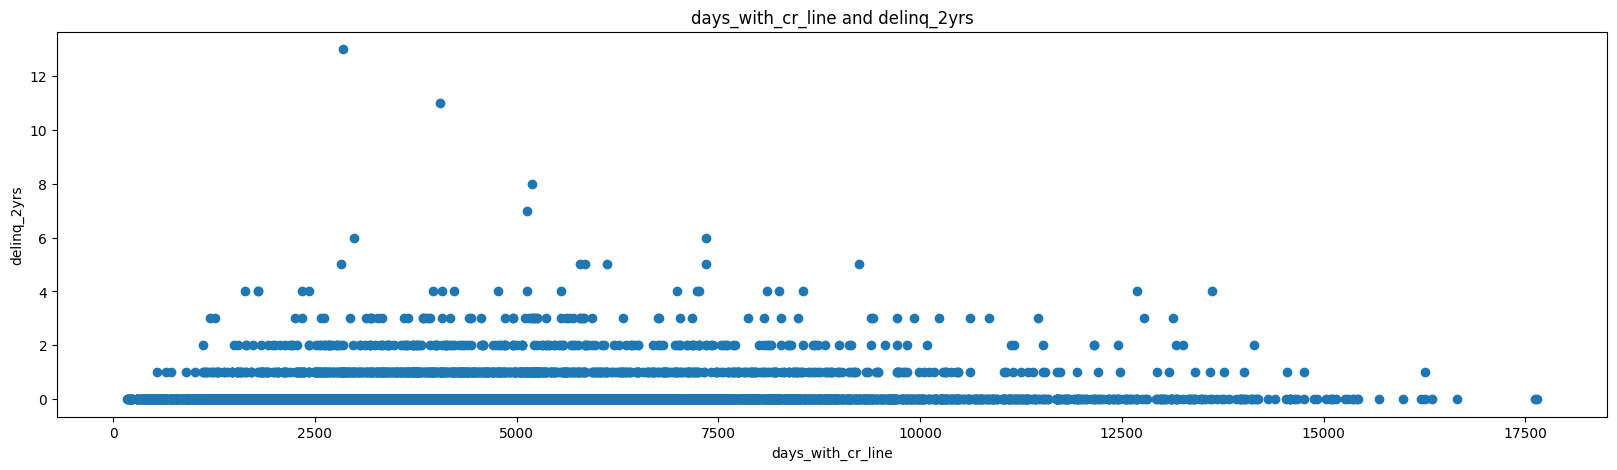

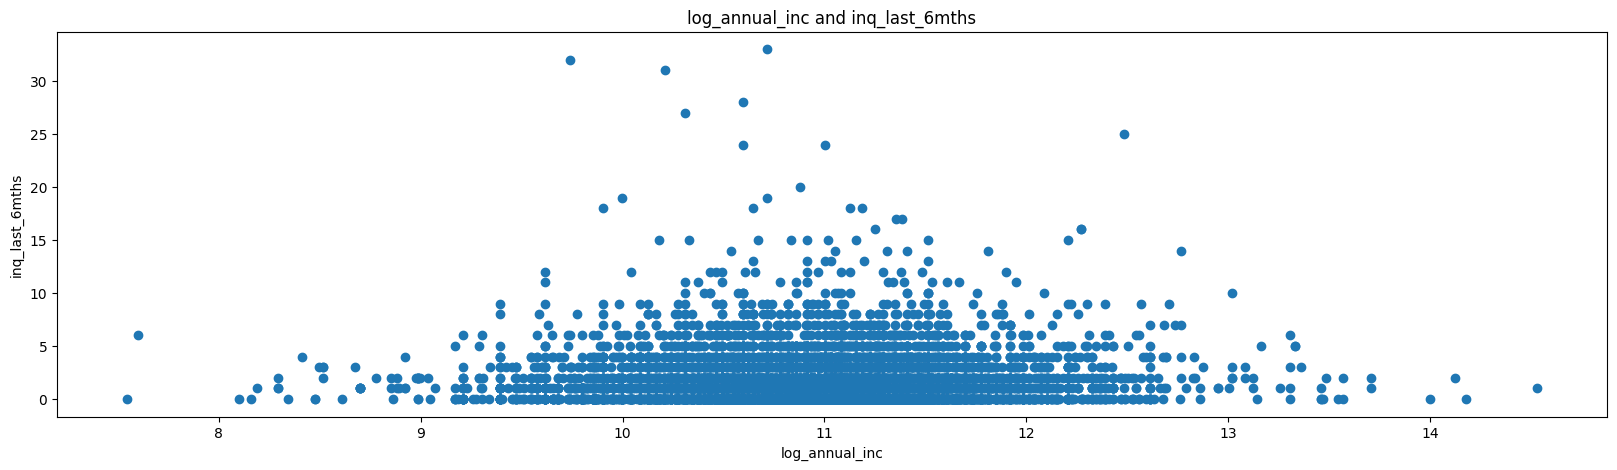

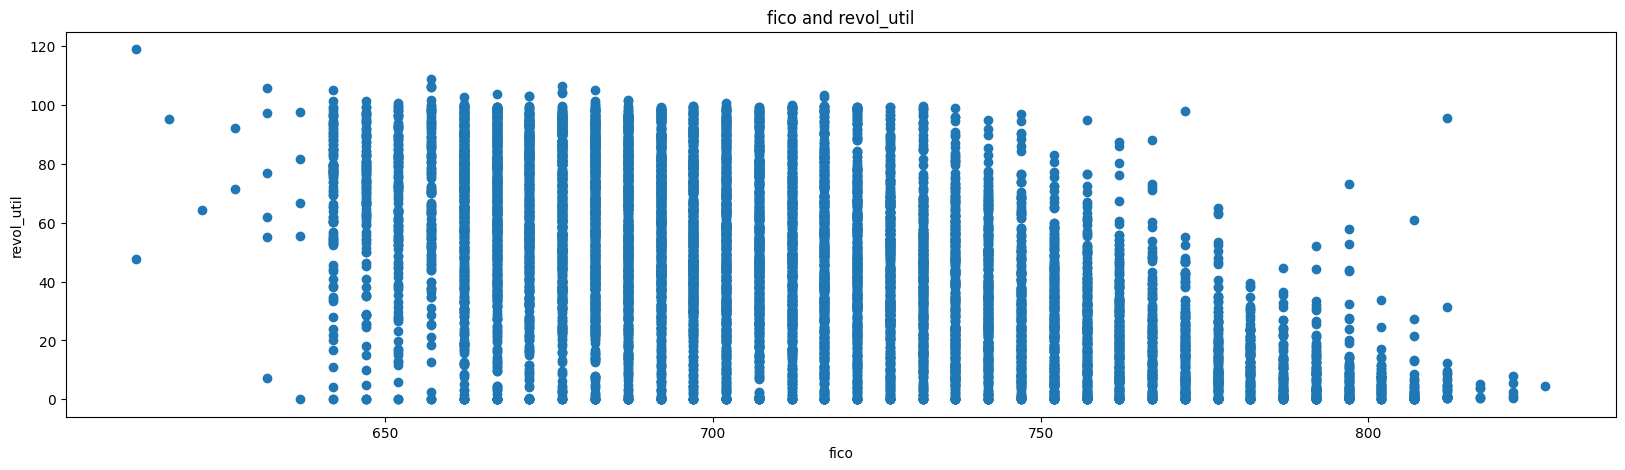

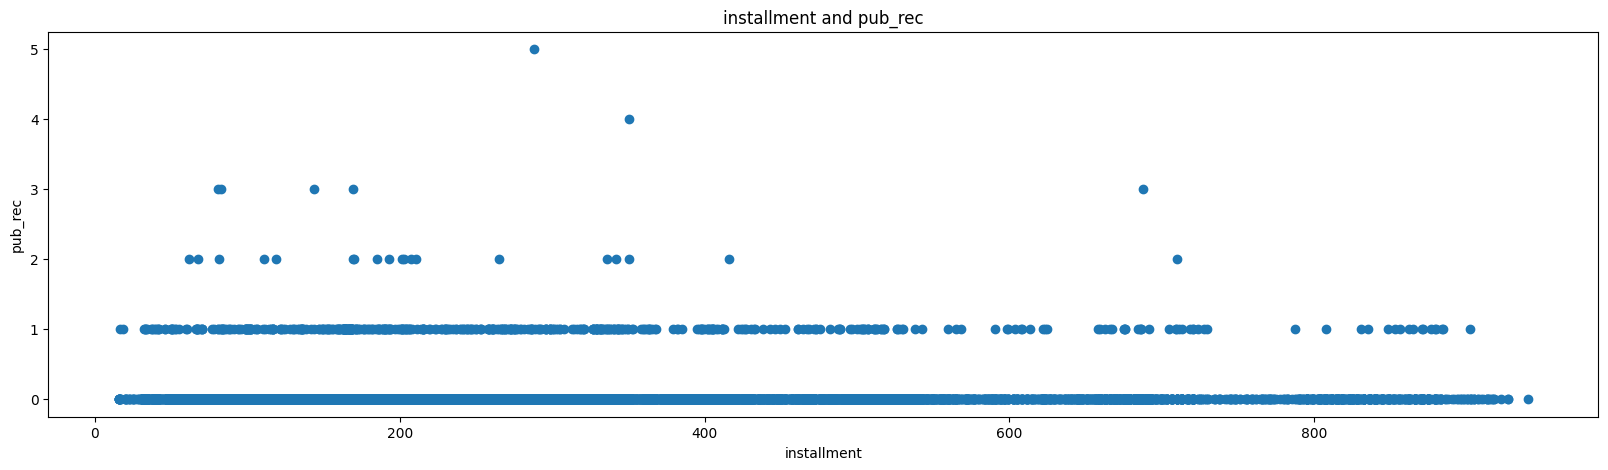

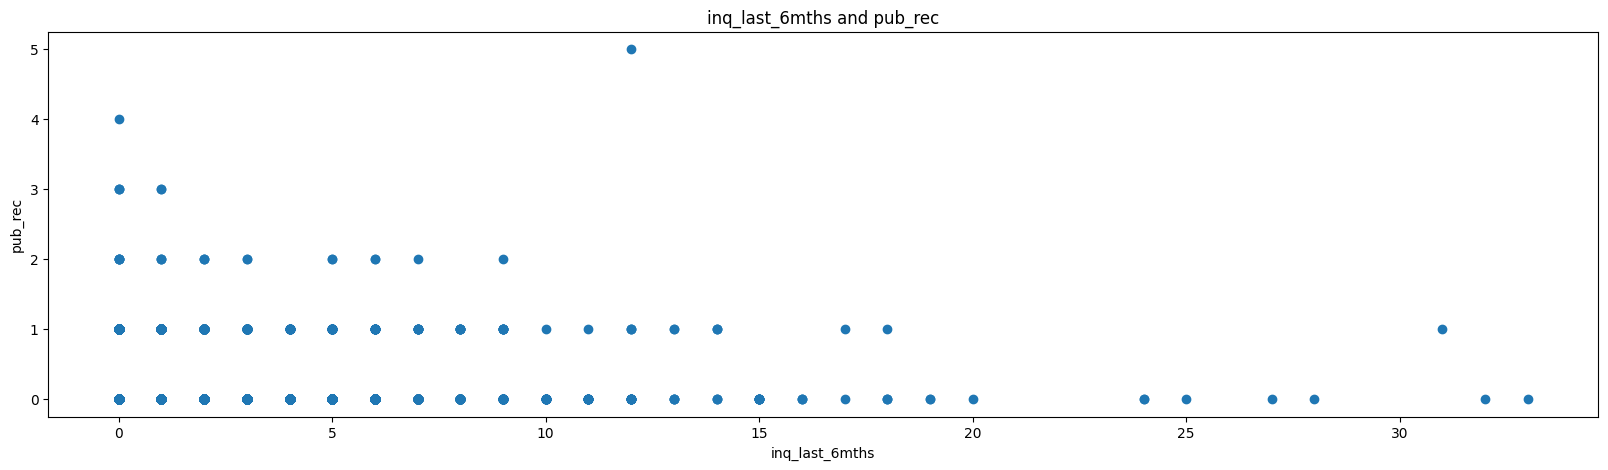

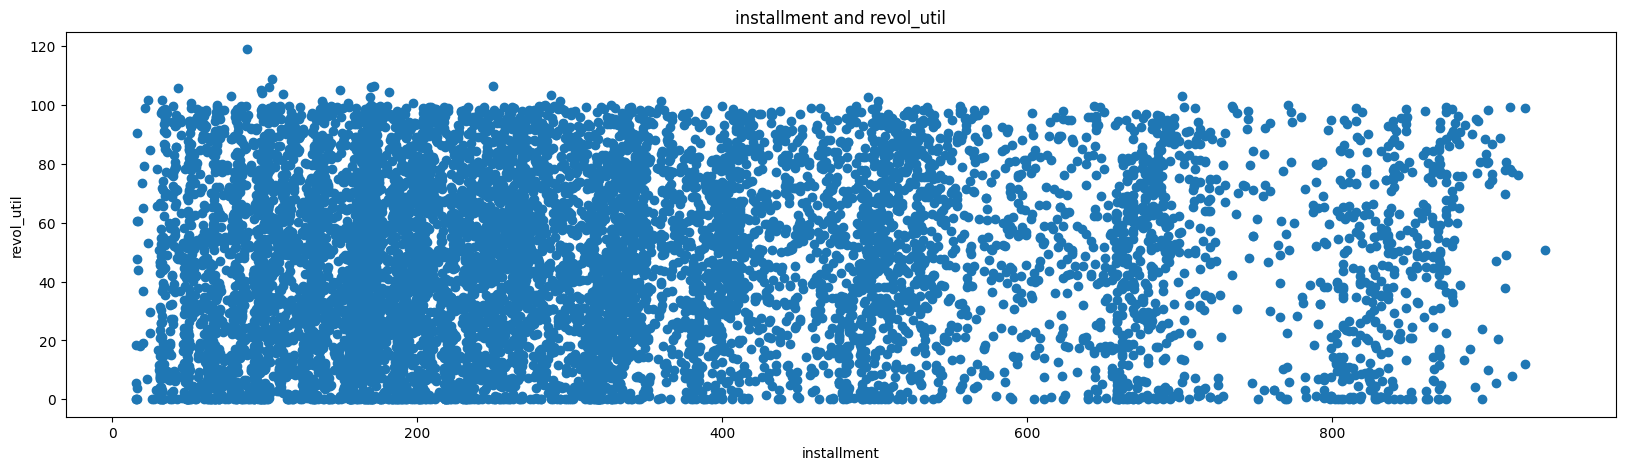

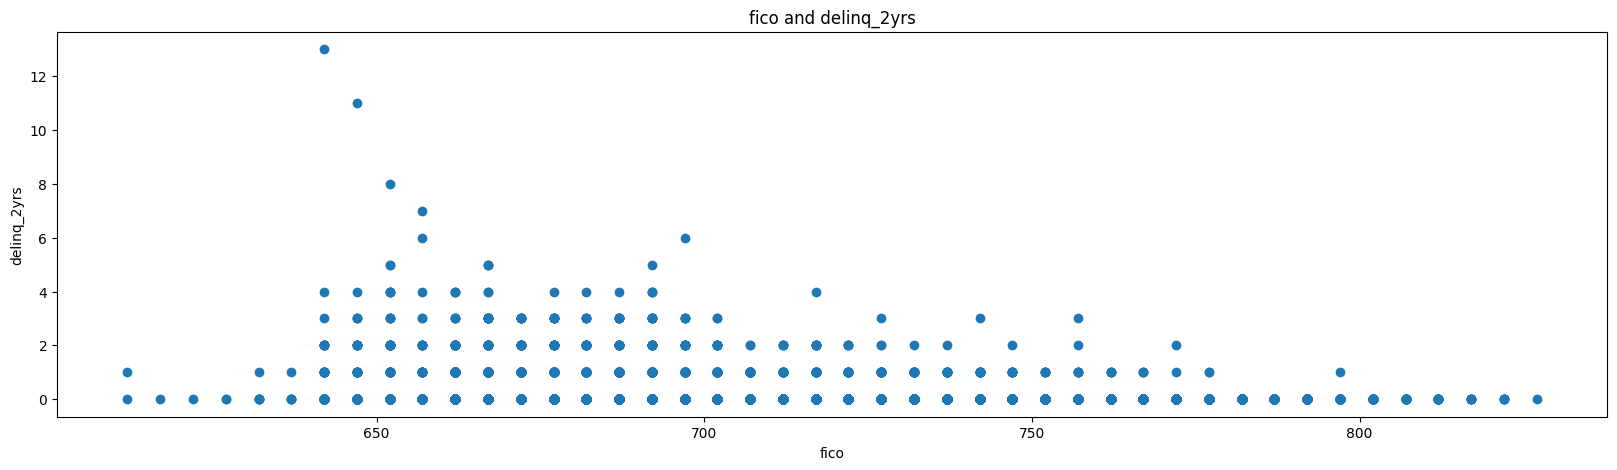

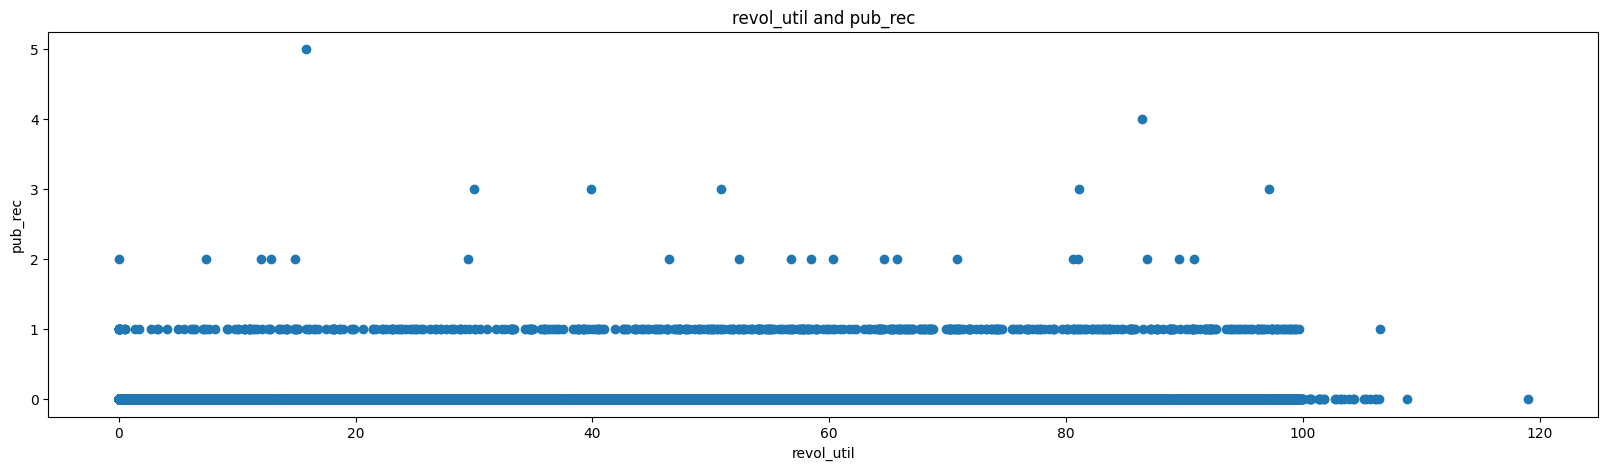

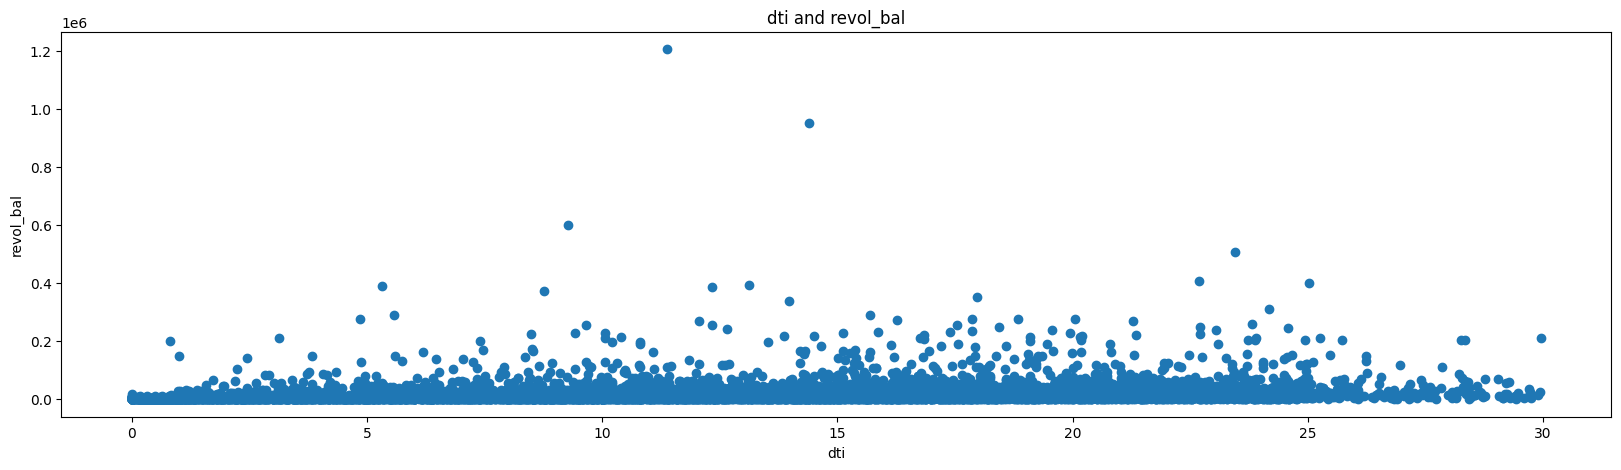

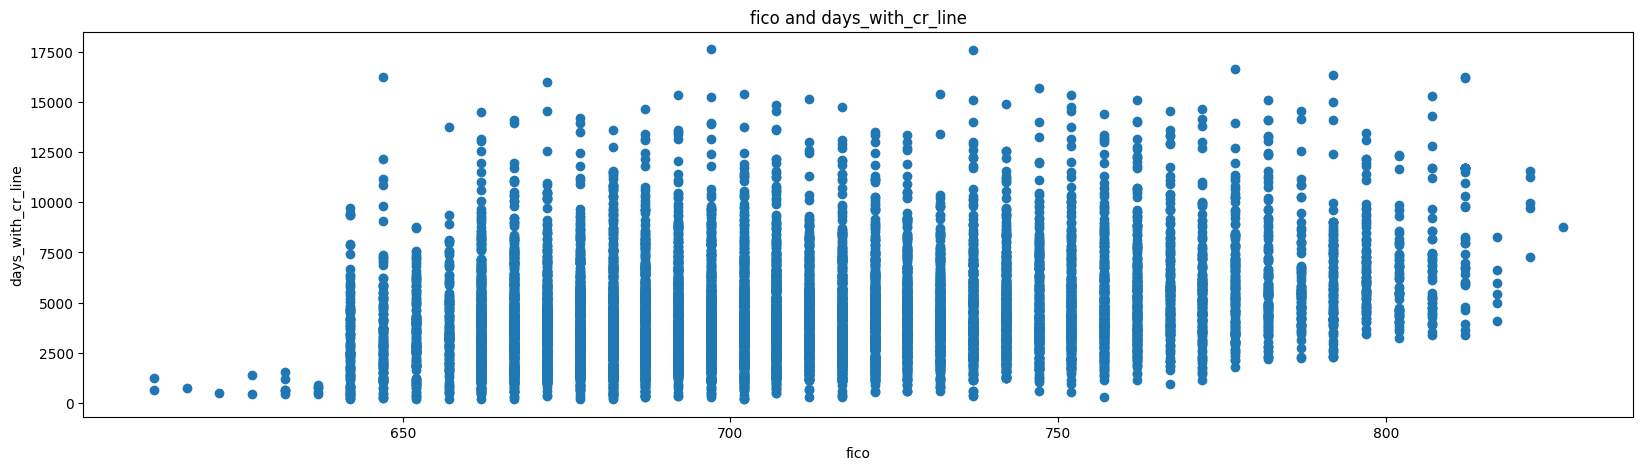

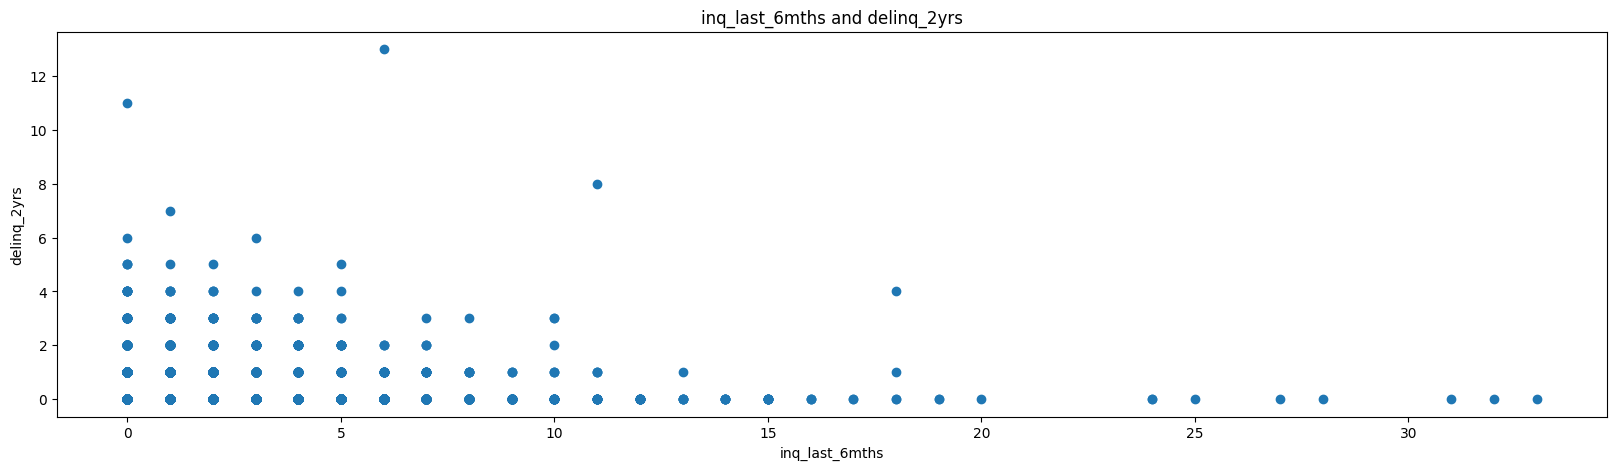

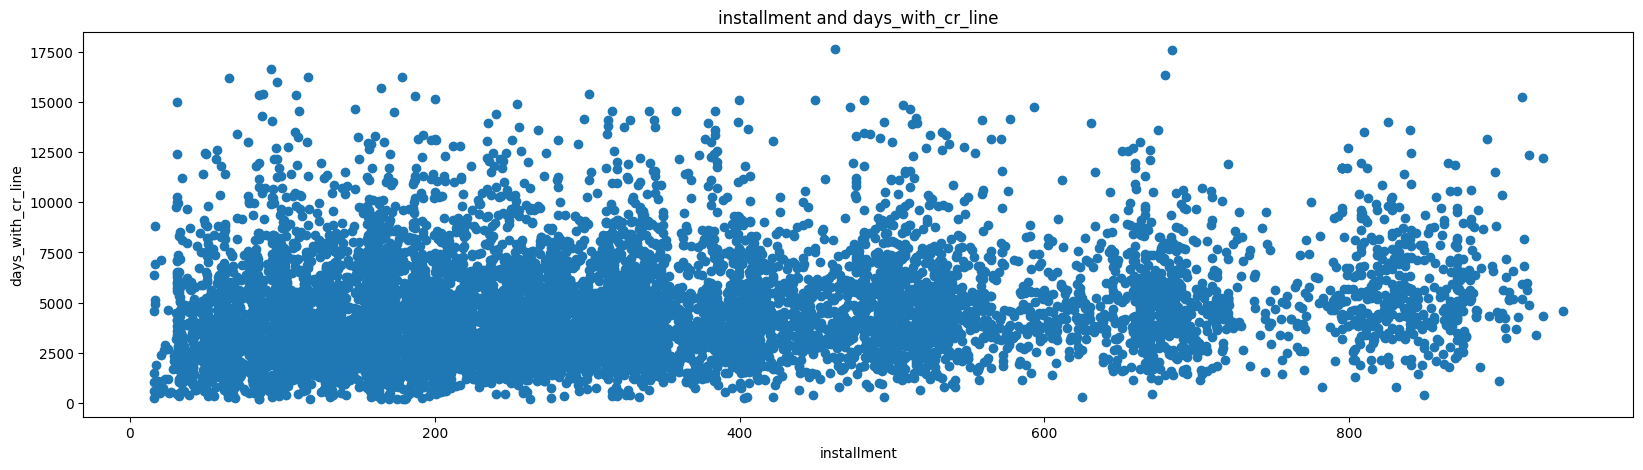

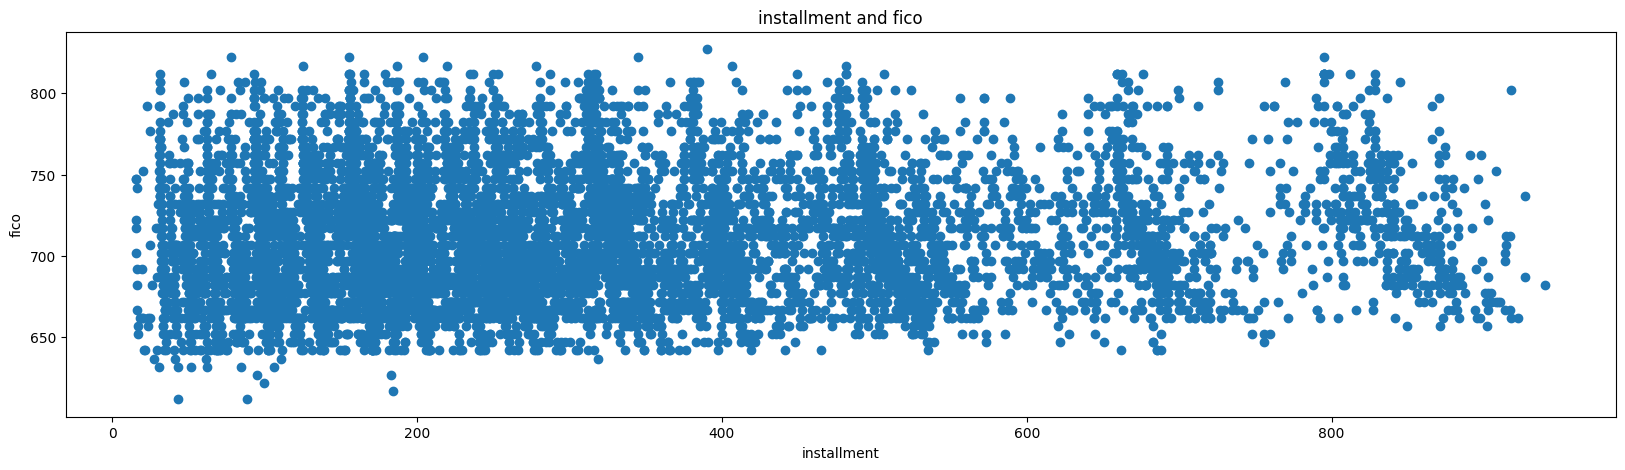

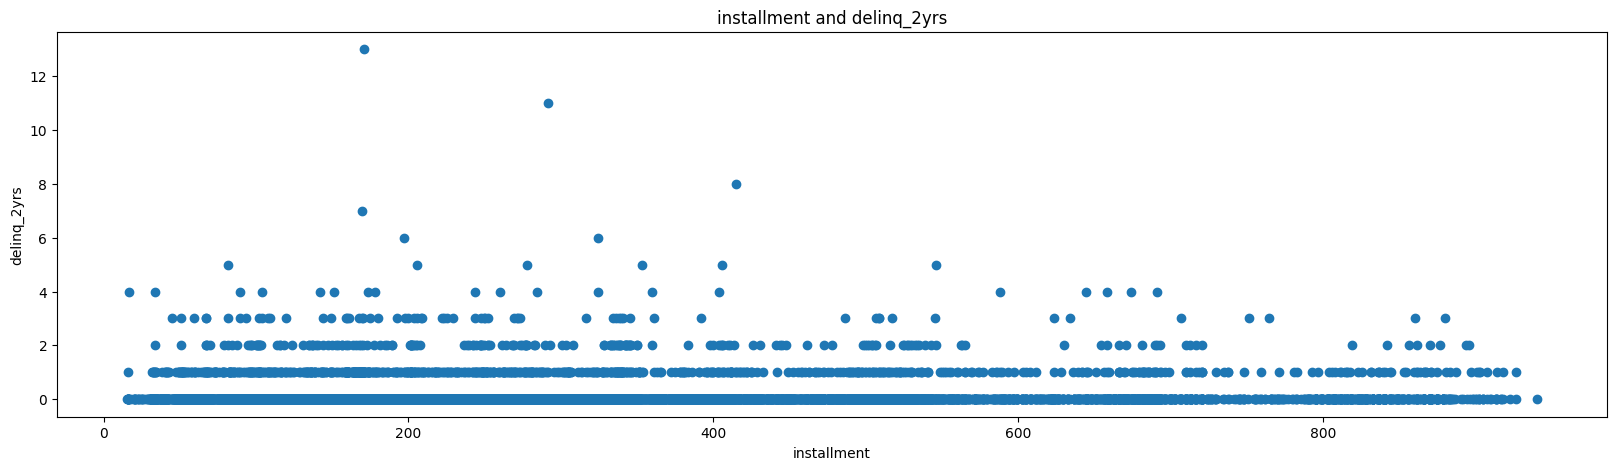

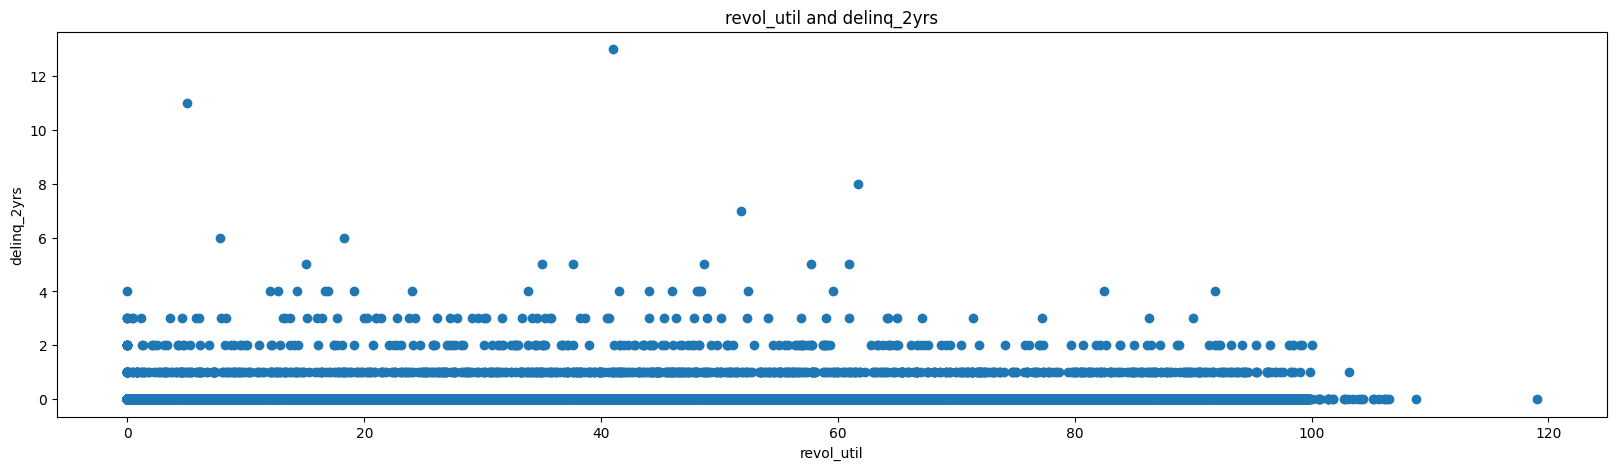

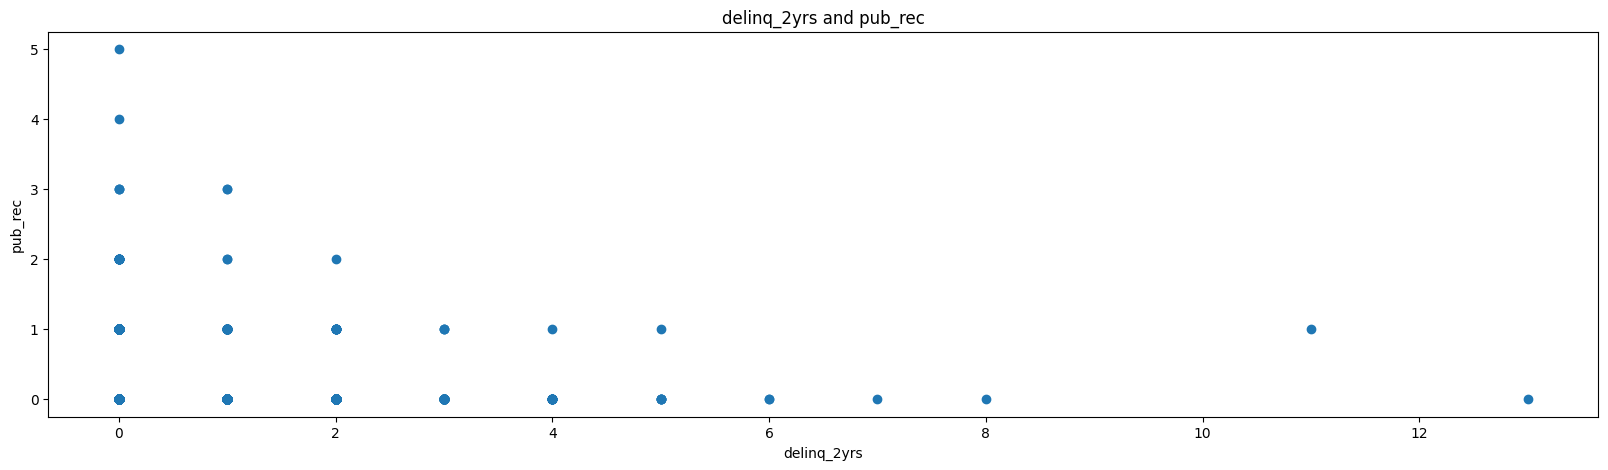

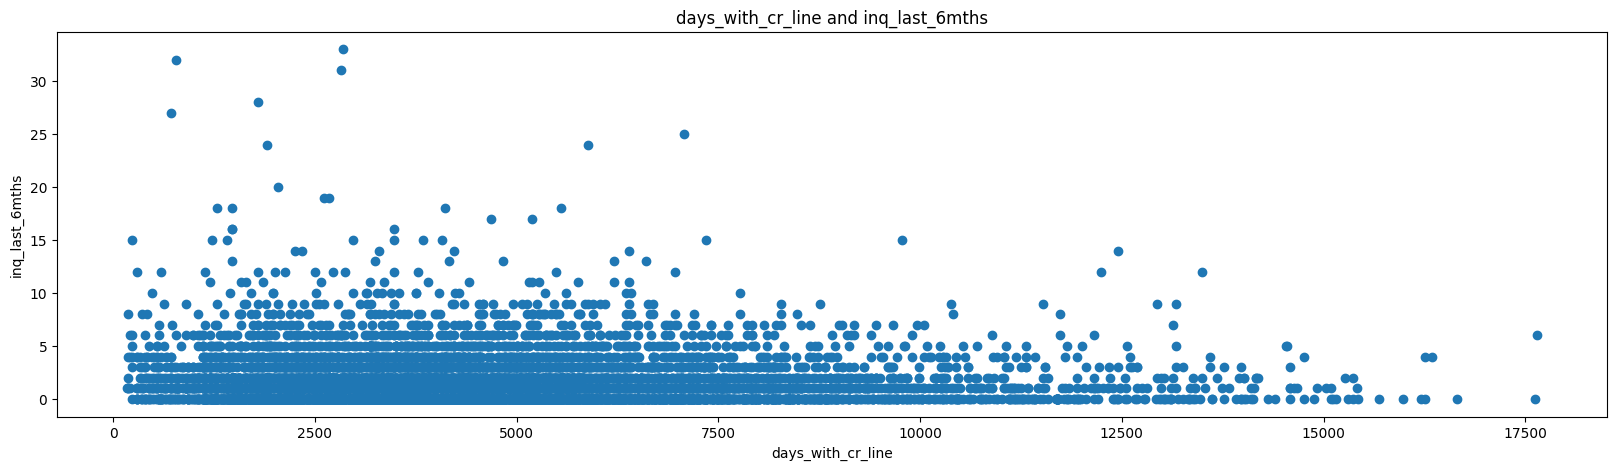

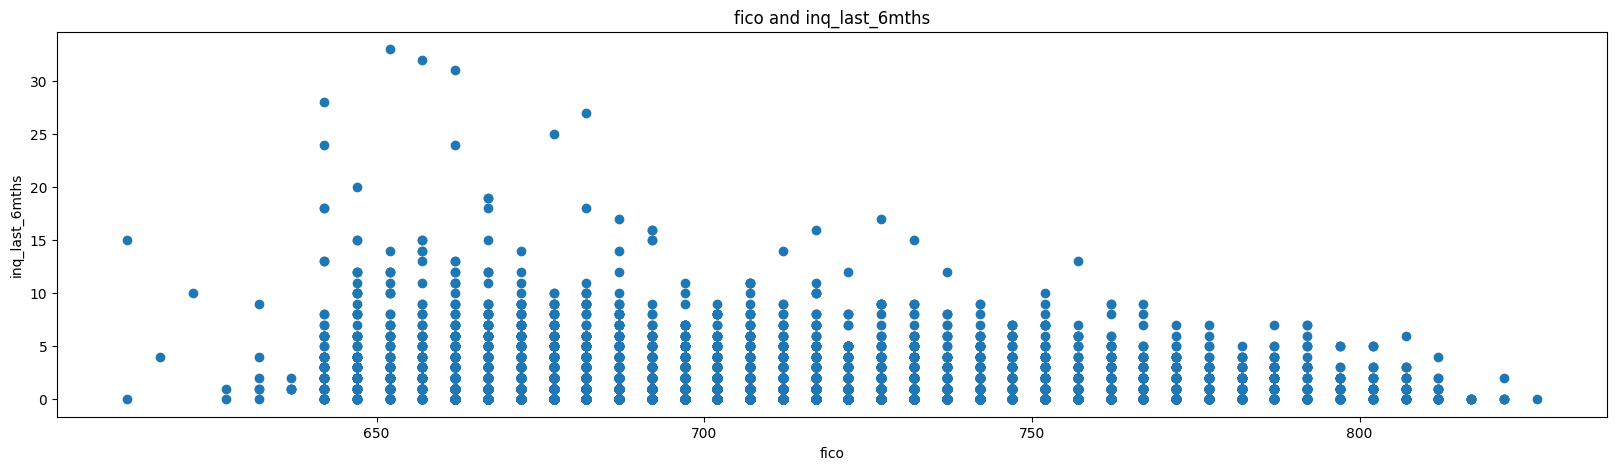

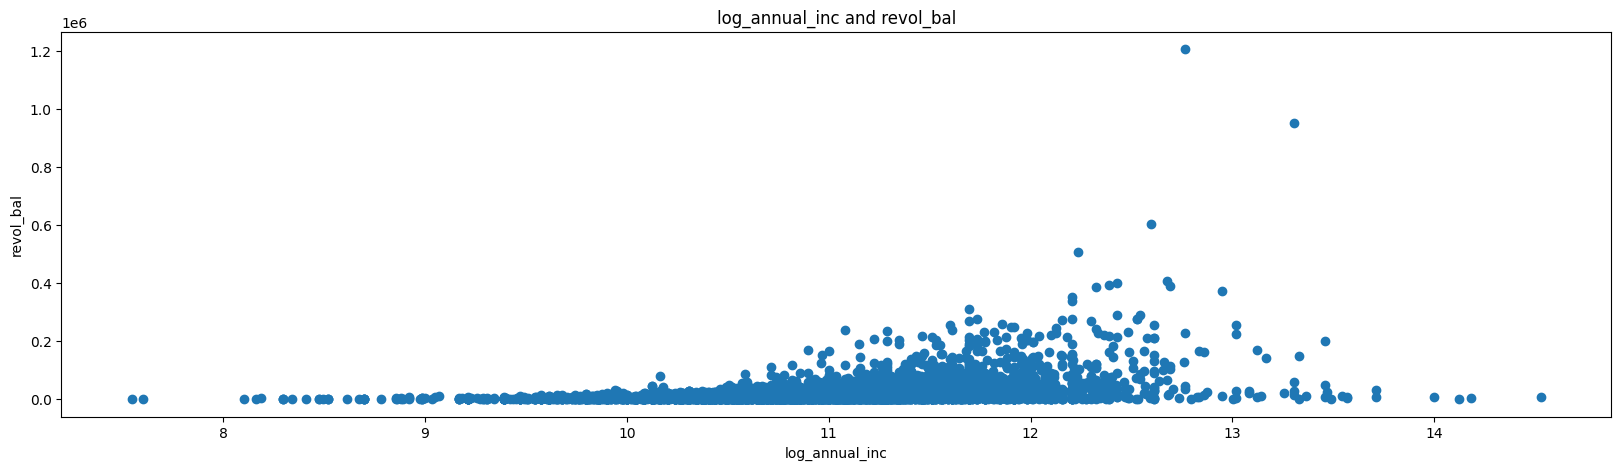

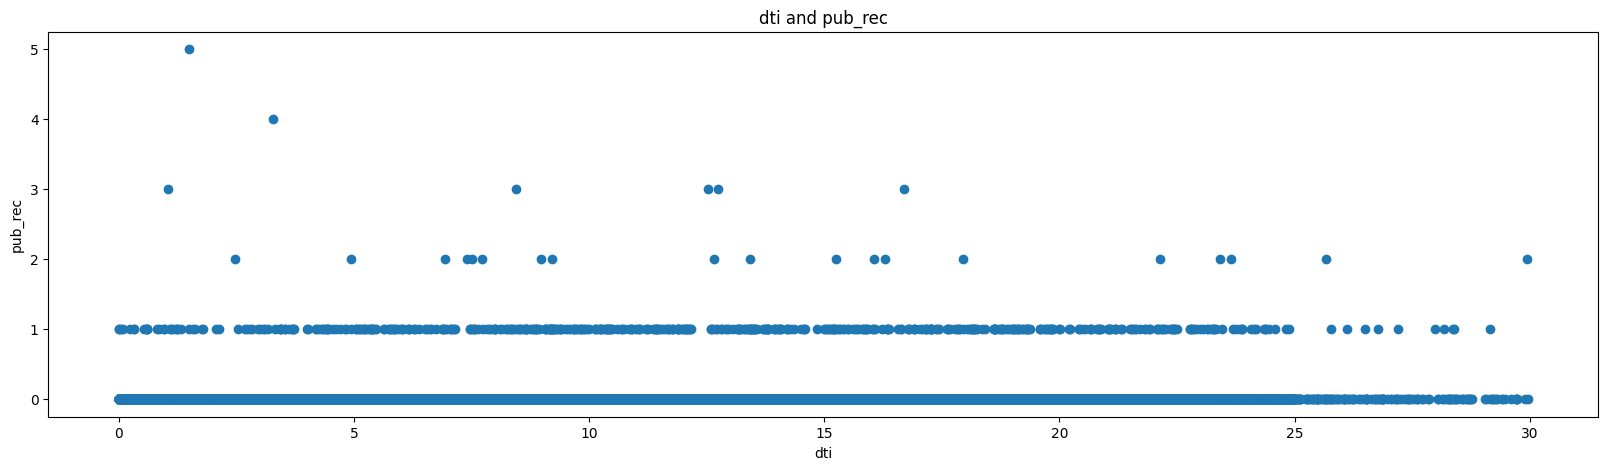

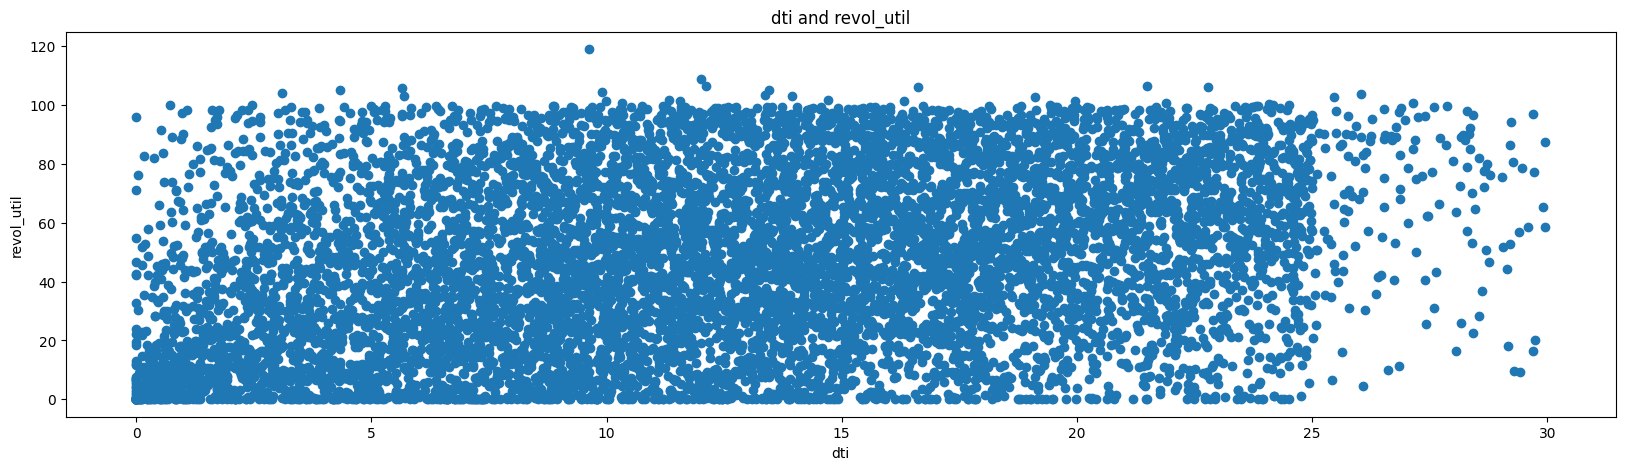

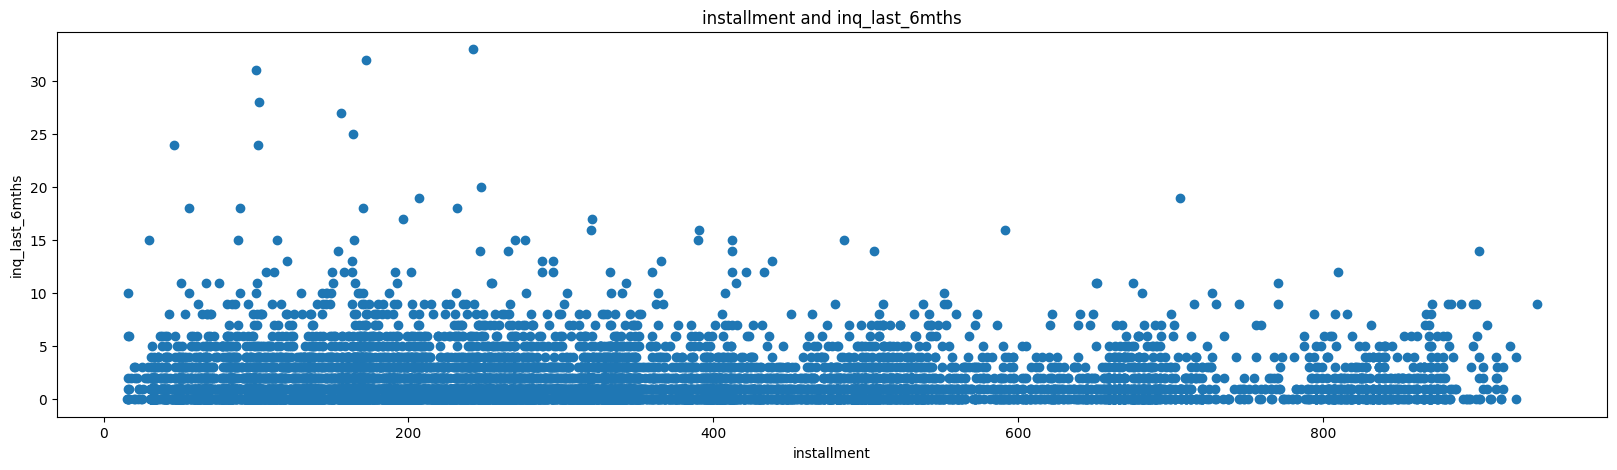

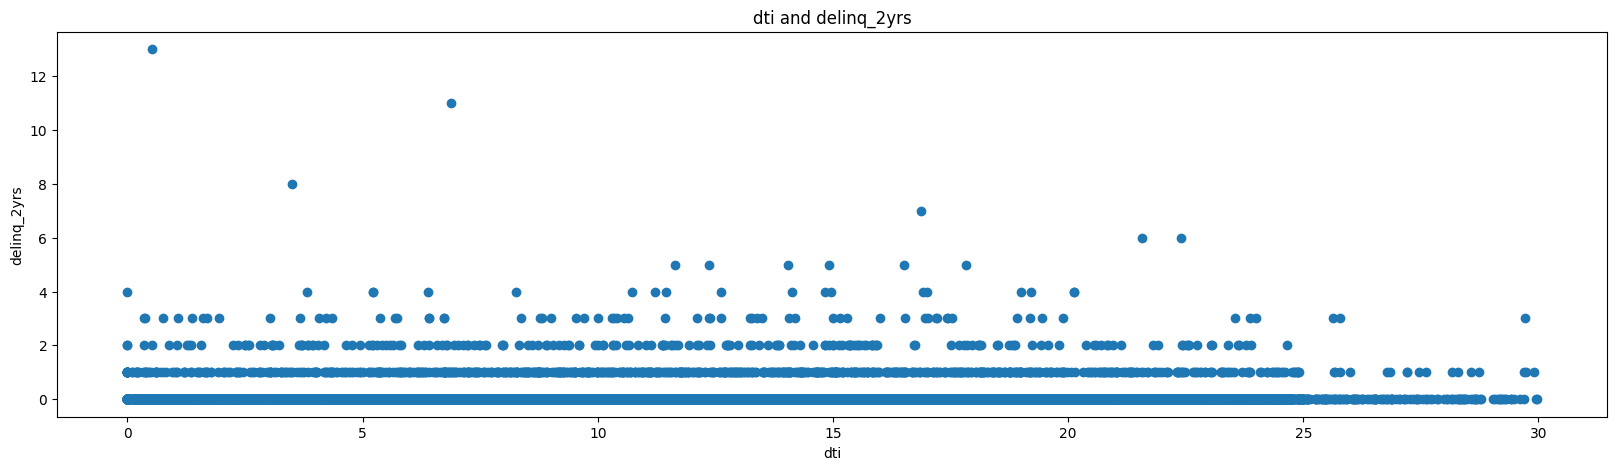

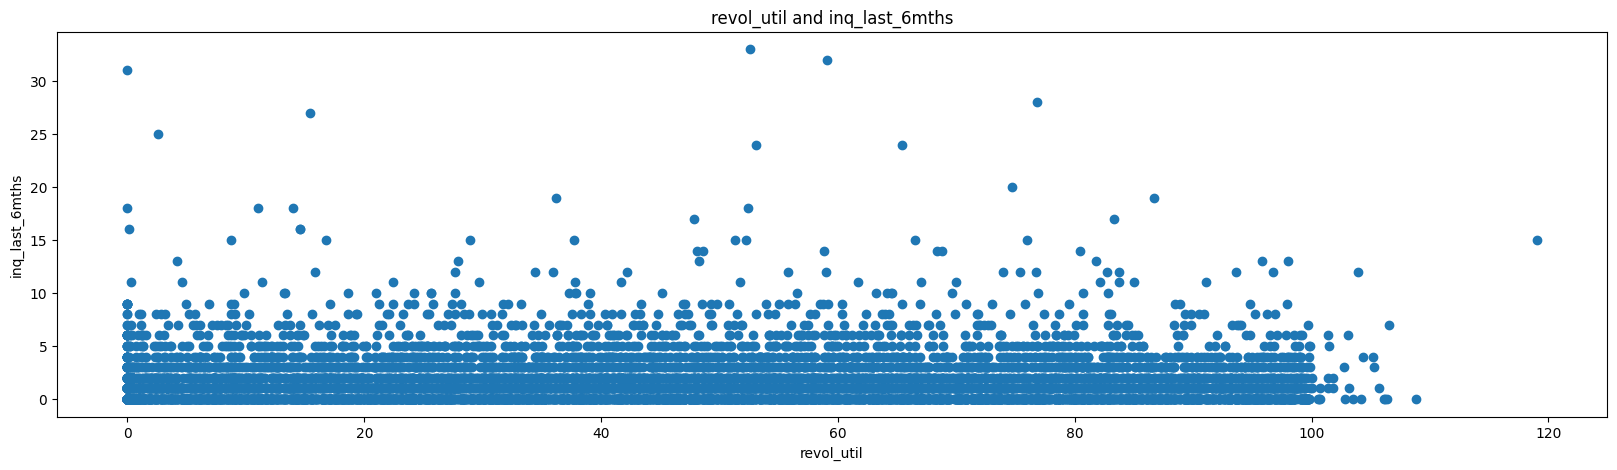

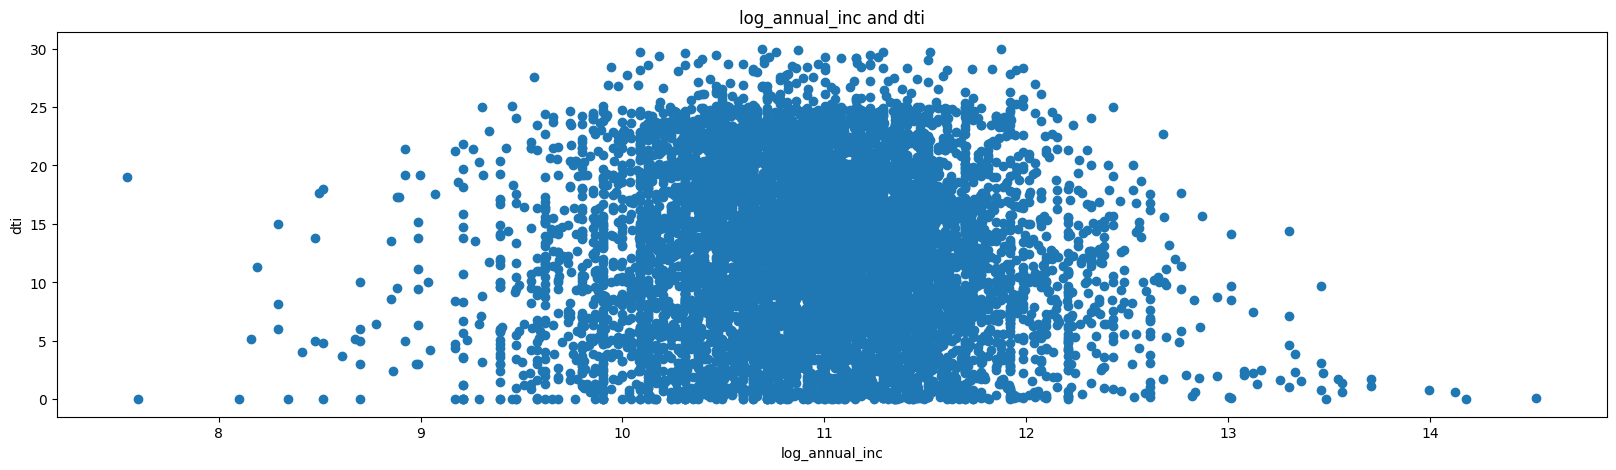

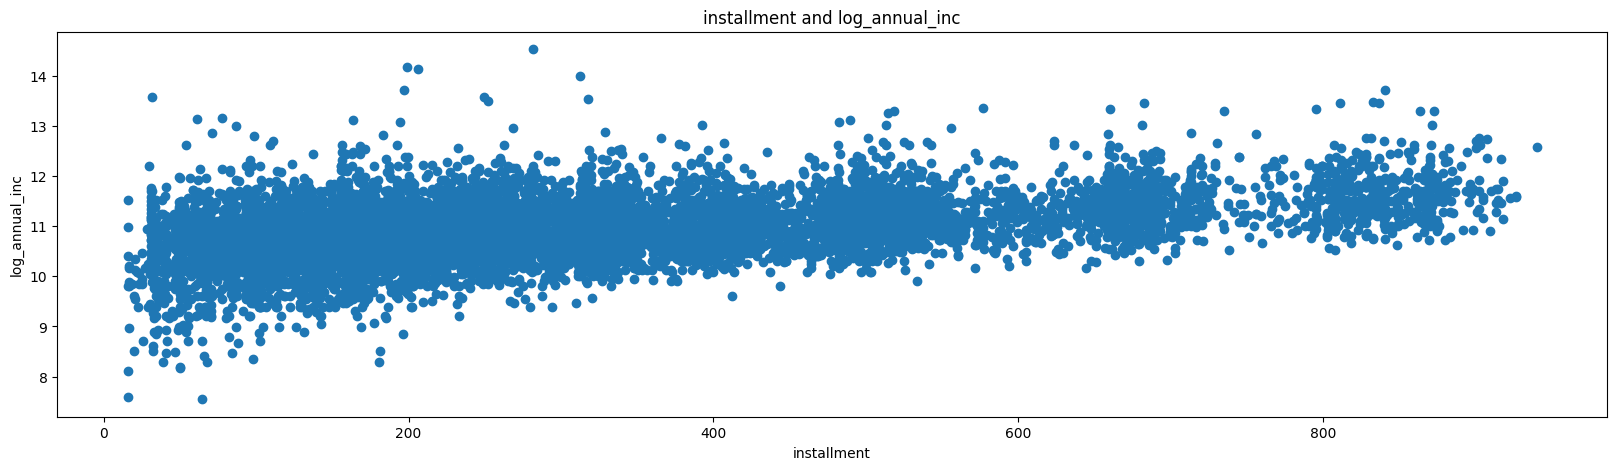

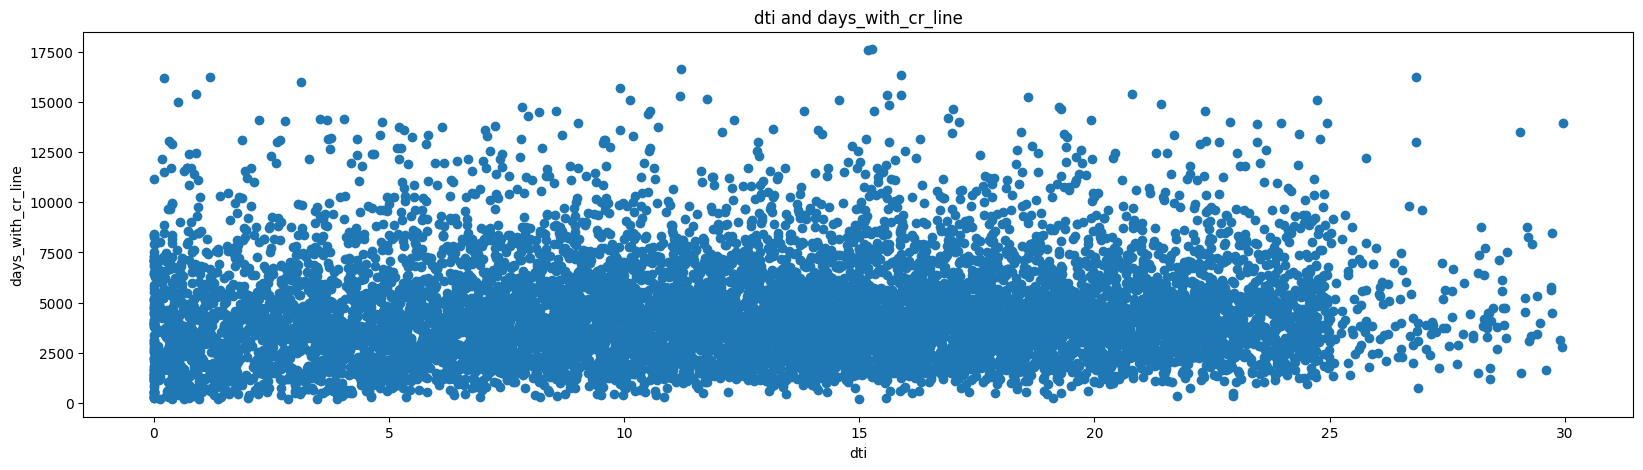

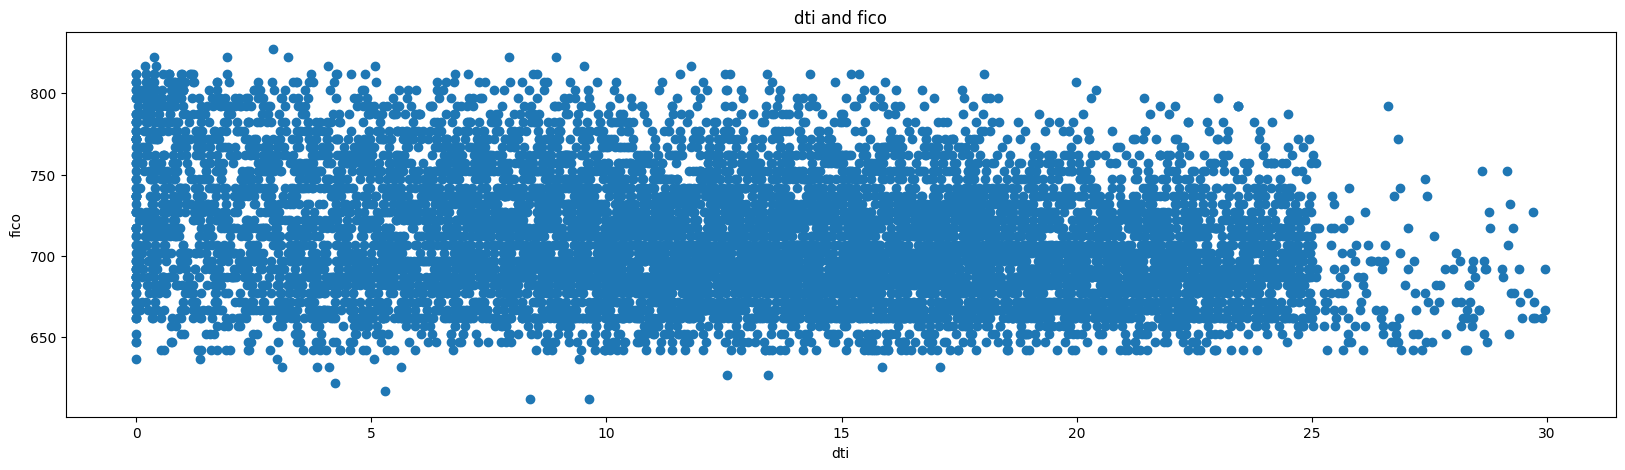

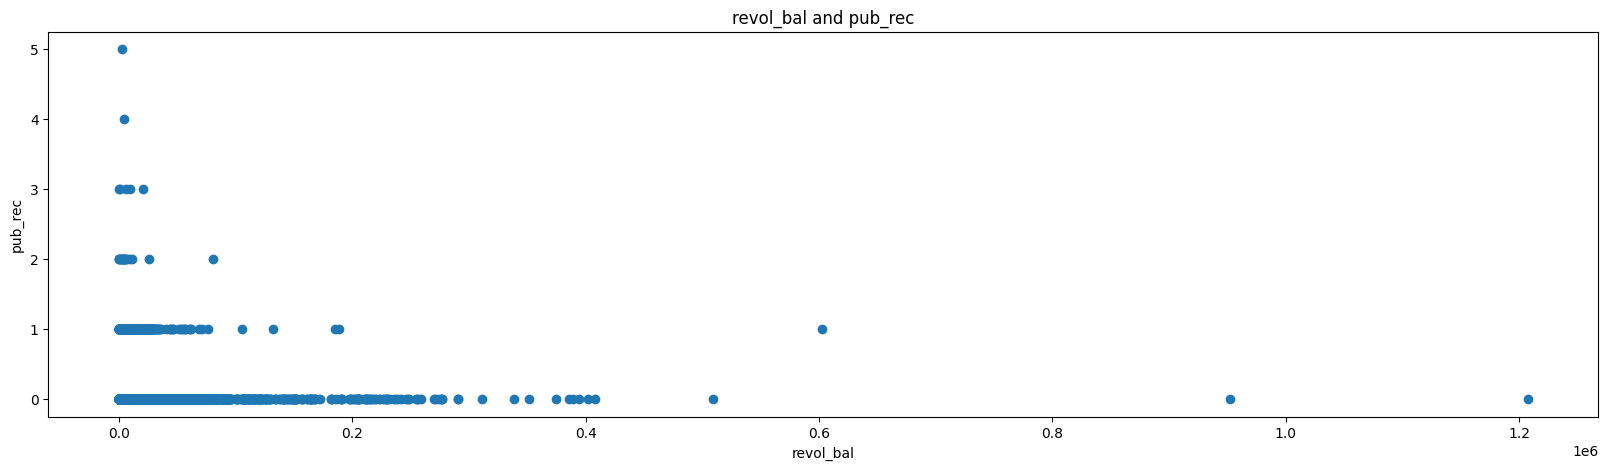

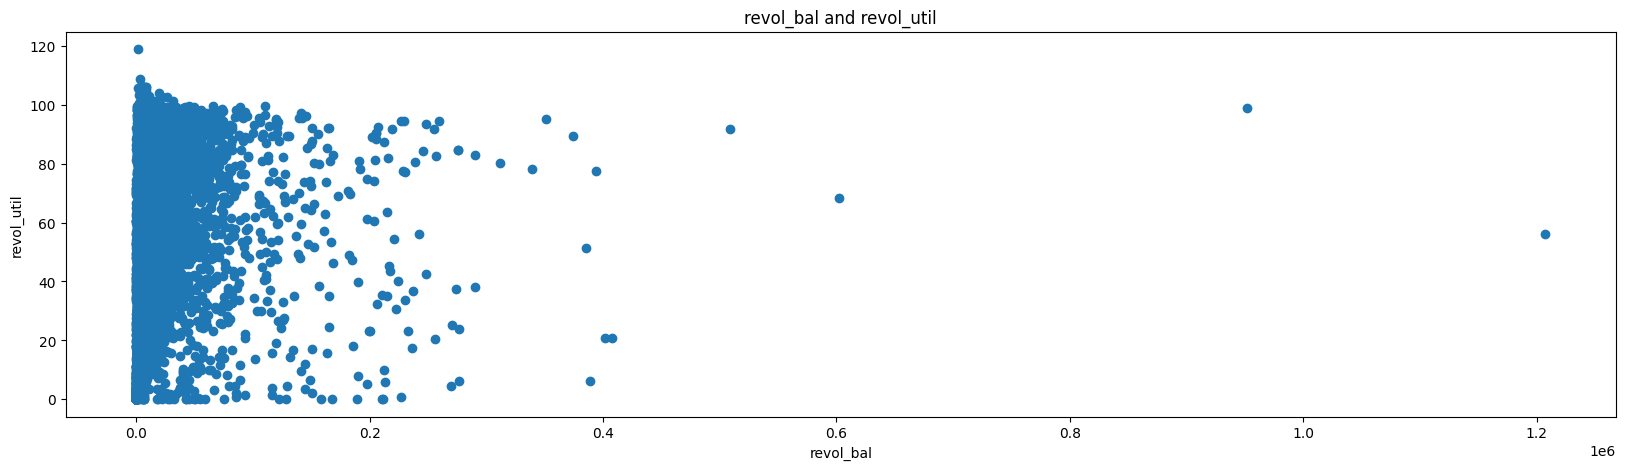

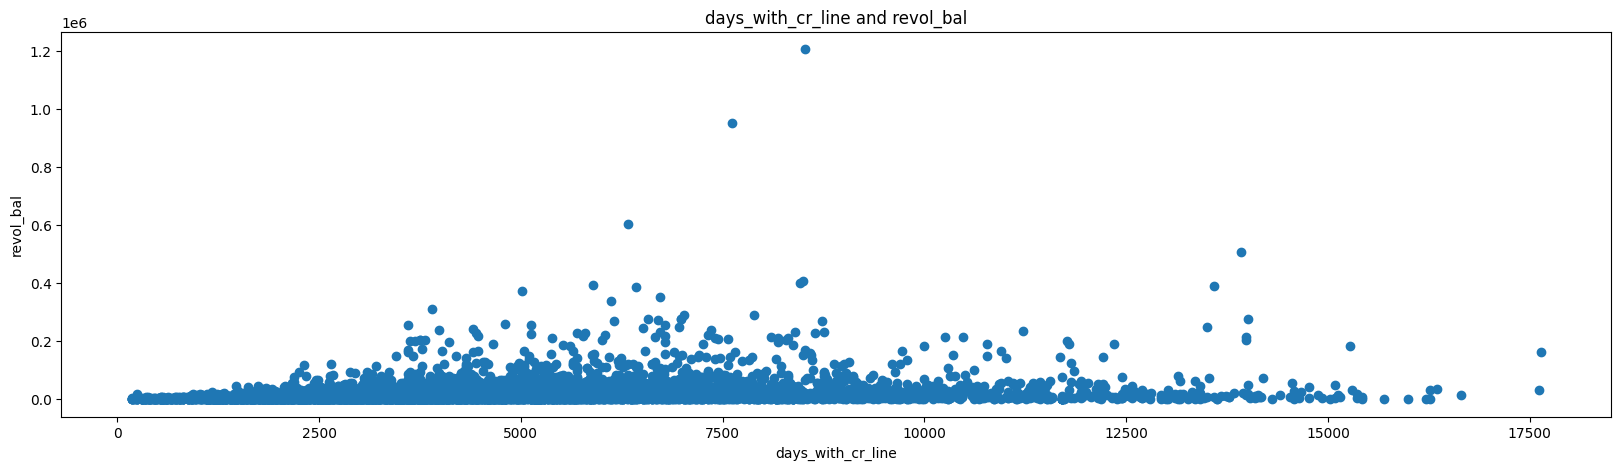

In [6]:
columns_to_plot = [column for column in df.columns if df[column].max() > 1]
unique_columns = set(itertools.combinations(columns_to_plot, 2))

for column_group in unique_columns:
    matplotlib.pyplot.scatter(x=df[column_group[0]], y=df[column_group[1]])
    matplotlib.pyplot.title(f"{column_group[0]} and {column_group[1]}")
    matplotlib.pyplot.xlabel(f"{column_group[0]}") 
    matplotlib.pyplot.ylabel(f"{column_group[1]}")
    matplotlib.pyplot.show()

The K-Means Clustering Model requires numerical data. It also assumes the data will follow normal numerical characteristics, meaning large numbers are greater than smaller numbers. Thus, the data needs to be on a similar scale. Reviewing the minimum and maximum values from the cell above, where `describe` was run, will show that some columns contain very large data points and others do not. Putting the data on the same scale will help the model to better generalize the patterns.

Scikit-learn provdes the method [`MinMaxScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) that can be used to normalize the data. `MinMaxScaler` uses a default range of 0-1 for normalization. This is the scale that will be used.

Create a variable called `min_max`, which will represent an instance of `MinMaxScaler()`. Pass in the `df` variable to the `fit_transform()` method, using `min_max_scale.fit_transform(df)`. This will return a data set that has been normalized, where all values will be on a scale from 0 to 1 (the default scale for `MinMaxScaler`). If you were to look at the data output from `MinMaxScaler`, you would see a list of lists of values. That represents the scaled version of the data. Convert it to a dataframe by passing in the `scaled_data` variable to `pandas.DataFrame()`, and specifying the columns as `min_max.get_feature_names_out()`. The output of that will be a dataframe, which has been saved to the variable `scaled_df`.

In [7]:
min_max = MinMaxScaler()
scaled_data = min_max.fit_transform(df)
scaled_df = pandas.DataFrame(scaled_data, columns=min_max.get_feature_names_out())
scaled_df.head()

,credit_policy,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1.0,0.376598,0.879888,0.544762,0.650200,0.581395,0.312754,0.023898,0.437815,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.301151,0.229916,0.506334,0.476969,0.441860,0.147818,0.027848,0.644538,0.000000,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.484015,0.379883,0.404820,0.388184,0.325581,0.259495,0.002908,0.215126,0.030303,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.260870,0.158653,0.544762,0.270360,0.465116,0.144379,0.027885,0.615126,0.030303,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.0,0.528133,0.094378,0.537503,0.499666,0.255814,0.222613,0.003926,0.331933,0.000000,0.076923,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


**Train a K-Means Clustering Model**

The [K-Means Clustering Model](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) provided by scikit-learn has several parameters that can be used when creating the model. Create a dictionary of `common_parameters` that will be used every time the K-Means model is trained. For our purposes, the parameters `init`, `n_init`, and `random_state` will be specified. The default values for the other parameters will be accepted.

The value for K in a K-Means Clustering Model is chosen at random. There are more scientific ways of determining which value is best for K, but having domain knowledge of the data and using intuition is a strategy for determining this value. For this example, 4 has been chosen as the number of clusters. Create a `kmeans` variable from a `KMeans()` model. Pass in the `common_parameters` dictionary using the two-asterisk method, which will unpack the key-value pairs. Also pass in `n_clusters=4`. Use the `fit()` method to train the K-Means Clustering Model on the data from `scaled_df`.

After training the model, retrieve the labels from `kmeans` using the `labels_` attribute. The `labels_` attribute provides the cluster in which each row of data was placed. There should be four different labels. Assign the label values to the new column `clusters` in `df`.

In [8]:
common_parameters = {"init": "k-means++", "n_init": 1, "random_state": 19}
kmeans = KMeans(n_clusters=4, **common_parameters)
kmeans.fit(scaled_df)
df["clusters"] = kmeans.labels_

**Validate the Quality of the K-Means Clustering Model**

Two assumptions of the K-Means clustering model are that the data clusters all have the same variance and that the data clusters are similar sizes, as mentioned above. Now that there is a trained K-Means Clustering Model, it can be tested for these two assumptions. 

Use [`numpy.var()`](https://numpy.org/doc/2.1/reference/generated/numpy.var.html) to calculate the variance on each of the clusters. The values saved in the columns `clusters` were the numbers 0-3, for four different clusters. We can create a for-loop to loop through a `range(0, 4)` of numbers 0 to 3 and then calculate the variance on the filtered down `df`. Each time the variance is calculated, add that information to the `variances` variable. Use the `variances` variable to create a `pandas.DataFrame()`.

A variance is considered similar to another if the values are close together. If they are not close together, then they are considered different. Some values seem to be close, such as `not_fully_paid` and `int_rate`. However, others have large differences between the variances, such as `installment` and all of the binary columns. This suggests that the K-Means' assumption of similar variances has been violated.

In [9]:
variances = []

for cluster in range(0, 4):
    variances.append(numpy.var(df.loc[df["clusters"] == cluster], axis=0))
variance_df = pandas.DataFrame(variances)
variance_df

,credit_policy,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,clusters
0,0.167507,0.000737,33941.968022,0.436709,50.380466,1604.078964,6.546608e+06,1.008958e+09,860.931047,5.215238,0.345639,0.052603,0.138459,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.000000,0.000622,46868.822514,0.467948,56.893403,913.920791,7.116487e+06,4.693840e+09,792.195085,12.146686,0.577653,0.126033,0.198287,0.0,0.145273,0.248776,0.060661,0.078005,0.045791,0.082211,0.0
2,0.000000,0.000560,38939.990146,0.282269,38.425180,1094.286326,5.278865e+06,2.358751e+08,711.277024,1.095785,0.204521,0.058824,0.111952,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,0.000000,0.000723,45717.586573,0.381216,44.210387,1409.629329,6.400246e+06,3.735187e+08,858.430917,1.520998,0.221922,0.064171,0.116769,0.0,0.236686,0.000000,0.086604,0.155789,0.120324,0.151813,0.0


If you questioned whether or not it mattered that the variance was not calculated on the scaled data, while the K-Means Clustering Model was trained on the scaled data, the below shows that the same columns show similar differences, just scaled to between 0 and 1.

In [10]:
scaled_df["clusters"] = kmeans.labels_
scaled_variances = []

for cluster in range(0, 4):
    scaled_variances.append(numpy.var(scaled_df.loc[scaled_df["clusters"] == cluster], axis=0))
scaled_variance_df = pandas.DataFrame(scaled_variances)
scaled_variance_df

,credit_policy,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,clusters
0,0.167507,0.030126,0.039715,0.008961,0.056128,0.034702,0.021472,0.000692,0.060796,0.004789,0.002045,0.002104,0.138459,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.000000,0.025431,0.054840,0.009602,0.063384,0.019771,0.023341,0.003220,0.055942,0.011154,0.003418,0.005041,0.198287,0.0,0.145273,0.248776,0.060661,0.078005,0.045791,0.082211,0.0
2,0.000000,0.022896,0.045563,0.005792,0.042809,0.023673,0.017314,0.000162,0.050228,0.001006,0.001210,0.002353,0.111952,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,0.000000,0.029560,0.053493,0.007823,0.049254,0.030495,0.020992,0.000256,0.060619,0.001397,0.001313,0.002567,0.116769,0.0,0.236686,0.000000,0.086604,0.155789,0.120324,0.151813,0.0


The last assumption to test is whether or not the clusters are similar sizes. This is a simple count of the values in the `clusters` column. The count shows that cluster 2 is the largest, and cluster 1 is the smallest. It seems to be the case that they are not similar sizes. Given the amount of data found in this dataset, I would want the differences to be more like cluster 3 and cluster 0, where there are differences but they look closer. There is not a hard and fast rule on how big of a difference matters, but it can be assumed that if you have many data points, larger differences can be more acceptable (think millions of rows of data). Given the large differences between some of the clusters, it would be safe to assume that this assumption has been violated.

In [11]:
df["clusters"].value_counts()

clusters
2    3223
3    2652
0    2331
1    1372
Name: count, dtype: int64

Another analysis on the K-Means Clustering Model is calculating the [`pairwise_distances`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise_distances.html) between the center points of each cluster. This will show you how far apart the centers are. If they are very close together, then it is likely that you have some groups that need to be combined, since there are very little differences between them.

Create the variable `euclidean_df` from a `pandas.DataFram()`, using the output of the `pairwise_distances()` test, from the passed-in `kmeans.cluster_centers_` values. In this example, the `metric='euclidean'` parameter has been used. `matplotlib.pyplot.imshow` will create a heatmap from the values in the `euclidean_df` dataframe. The purple squares are those center points that are exactly the same, which makes sense because each one represents the comparison of each group with itself. The other groups show that there are greater differences between `0` and `1` and `0` and `2`. There are smaller differences between the other groups. However, there are still differences. It is possible that there are more differences between our groups than the other tests have suggested.

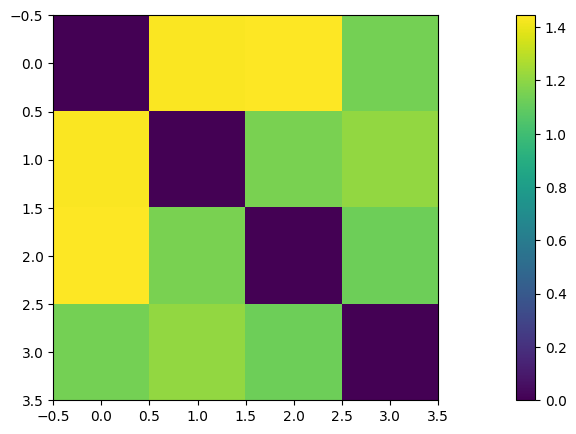

,0,1,2,3
0,0.000000,1.435472,1.444738,1.142909
1,1.435472,0.000000,1.154435,1.212091
2,1.444738,1.154435,0.000000,1.127136
3,1.142909,1.212091,1.127136,0.000000


In [12]:
euclidean_df = pandas.DataFrame(pairwise_distances(kmeans.cluster_centers_, metric='euclidean'))
matplotlib.pyplot.imshow(euclidean_df)
matplotlib.pyplot.colorbar()
matplotlib.pyplot.show()
euclidean_df

**Another Strategy for Finding the K in K-Means Clustering**

As mentioned above, one strategy for determining K in K-Means is to guess, using domain knowledge of the data. However, there are other methods that are more scientific. One such method is known as the Elbow-Method. It involves training a K-Means Clustering Model on a range of cluster values, then calculating the [inertia or distortion](https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/) of each of the trained models and and plotting that value. The plot will result in a line graph. The point at which the decrease in the value of the inertia or distortion levels out is typically considered to be the best number for the clusters.

Create a list variable called `inertias`. Loop through a `range()` of numbers, representing the `cluster` value of a K-Means Clustering Model. For the amount of data in `scaled_df`, a range of `1` to `14` is likely sufficient. The for-loop will train a `KMeans()` model each time, passing in the `n_clusters` value and the `common_parameters` dictionary created above. Add the `inertia_` attribute of the `kmeans` trained model to `inertias` each loop. 

After the loop, create a dataframe from a dictionary of `n_clusters` and `inertia`, using `range(1, 15)` and `inertias` as the data. Plot the data using a line graph and provide labels to make the plot readable. Adding `xticks` will keep `matplotlib.pyplot` from truncating the x-tick values.

There are three spots where the elbow changes directions, which creates an "elbow" in the plot. The first change is at `2`, then `3`, and finally `4`. Given this plot, our first guess of `4` clusters was likely a good guess. However, it also looks like `2` and `3` may be some models to review. Since our data violated the basic assumptions of the K-Means Clustering Model, there are likely some things that could be done to improve the output of the data. This would be a good opportunity to review the data and determine if there are columns that are less useful to the training of the model and possibly remove them or it may be necessary to increase the amount of data collected.

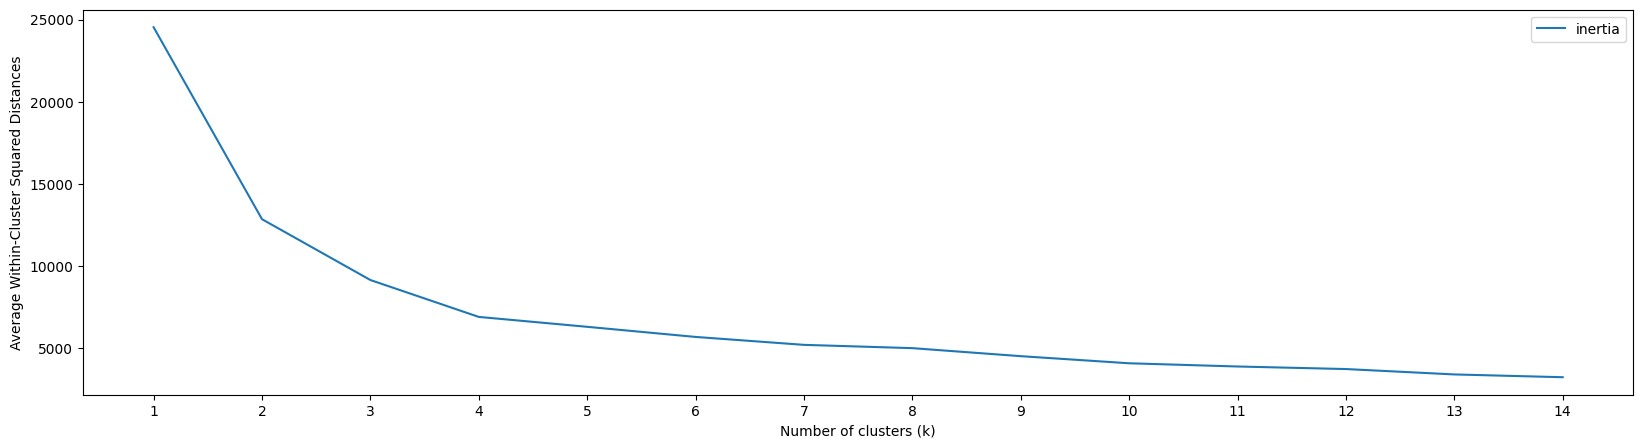

In [13]:
inertias = []
for n_cluster in range(1, 15):
    kmeans = KMeans(n_clusters=n_cluster, **common_parameters).fit(scaled_df)
    inertias.append(kmeans.inertia_)
inertia_df = pandas.DataFrame({'n_clusters': range(1, 15), 'inertia': inertias})
inertia_df.plot(x='n_clusters', y='inertia')
matplotlib.pyplot.xlabel('Number of clusters (k)')
matplotlib.pyplot.ylabel('Average Within-Cluster Squared Distances')
matplotlib.pyplot.xticks(range(1, 15))
matplotlib.pyplot.show()